In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt


# 1) Oracle Summaries laden
oracle_dir = Path("./results")  # anpassen
files = sorted(oracle_dir.glob("summary_*.csv"))

oracle = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)

# Vereinheitlichen: nur Datum
#oracle["day"] = pd.to_datetime(oracle["day"], errors="coerce").dt.normalize()

oracle["day"] = pd.to_datetime(oracle["day"].astype(str).str.slice(0, 10), errors="coerce")
oracle["day"] = oracle["day"].dt.normalize()

# 2) RI_base aus combo_id==0 ziehen
ri_base = (
    oracle.loc[oracle["combo_id"] == 0, ["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
    .drop_duplicates(subset=["day"])
)

# 3) Alle "synthetic" Runs (ohne combo 0)
syn = oracle.loc[oracle["combo_id"] != 0].copy()

# 4) Baseline an synthetic dranhängen
syn = syn.merge(ri_base, on="day", how="left")

# Prozentualer uplift je combo
syn["uplift_pct"] = (syn["profit"] - syn["RI_base"]) / syn["RI_base"] * 100

# 5) Tages-Übersicht bauen
summary = (
    syn.groupby("day")
    .apply(lambda g: pd.Series({
        "RI_base": g["RI_base"].iloc[0],
        "Oracle_max": g["profit"].max(),
        "Oracle_max_pct": (g["profit"].max() - g["RI_base"].iloc[0]) / g["RI_base"].iloc[0] * 100,
        "n_better_than_base": (g["profit"] > g["RI_base"]).sum(),
        "mean_uplift": g["uplift_pct"].mean(),
        "median_uplift": g["uplift_pct"].median(),
        "mean_uplift_pct_if_better": g.loc[g["profit"] > g["RI_base"], "uplift_pct"].mean(),
        "median_uplift_pct_if_better": g.loc[g["profit"] > g["RI_base"], "uplift_pct"].median(),
    }))
    .reset_index()
)

# Optional: NaNs (falls kein Run besser ist) auf 0 setzen
summary[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]] = (
    summary[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]].fillna(0.0)
)

# Speichern
out_path = oracle_dir / "oracle_overview_by_day.csv"
summary.to_csv(out_path, index=False)

print("Saved:", out_path)
summary.head()



Saved: results/oracle_overview_by_day.csv


/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_85743/4255858479.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,day,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift,median_uplift,mean_uplift_pct_if_better,median_uplift_pct_if_better
0,2019-01-01,68.233139,119.010039,74.416772,142.0,-0.015511,-2.473703,21.450609,17.686777
1,2019-01-02,159.440419,211.961910,32.941140,168.0,-5.789768,5.125578,16.861342,17.855675
2,2019-01-03,56.598649,70.577425,24.698074,38.0,-21.170281,-18.153606,7.912128,5.888537
3,2019-01-04,64.915423,81.637881,25.760378,29.0,-23.103862,-23.112231,5.272558,3.797980
4,2019-01-05,102.020127,123.676087,21.227145,3.0,-28.007618,-23.736612,12.765820,10.157263


In [804]:
#summary = summary.loc[summary["day"] < pd.Timestamp("2020-12-31")].copy()

In [253]:
summary = summary.rename(columns={"Oracle_max": "combinations_max", "Oracle_max_pct": "combinations_max_pct"})
summary = summary.drop(columns=["day"])

In [254]:
summary.describe().round(0)

,RI_base,combinations_max,combinations_max_pct,n_better_than_base,mean_uplift,median_uplift,mean_uplift_pct_if_better,median_uplift_pct_if_better
count,1496.0,1496.0,1496.0,1496.0,1496.0,1496.0,1496.0,1496.0
mean,175.0,207.0,27.0,125.0,-3.0,-3.0,9.0,8.0
std,157.0,174.0,36.0,79.0,18.0,18.0,15.0,15.0
min,18.0,32.0,-2.0,0.0,-49.0,-55.0,0.0,0.0
25%,67.0,87.0,12.0,59.0,-10.0,-9.0,4.0,3.0
50%,110.0,138.0,18.0,119.0,-2.0,-2.0,6.0,5.0
75%,239.0,281.0,32.0,187.0,2.0,2.0,10.0,9.0
max,1359.0,1700.0,751.0,298.0,401.0,415.0,402.0,416.0


In [ ]:
summary.dtypes

number_of_days                 datetime64[ns]
RI_base                               float64
combinations_max                      float64
combinations_max_pct                  float64
n_better_than_base                    float64
mean_uplift                           float64
median_uplift                         float64
mean_uplift_pct_if_better             float64
median_uplift_pct_if_better           float64
dtype: object

In [806]:
summary.to_csv(oracle_dir / "oracle_overview_summary_stats.csv", index=False)

In [807]:
# enrich summary files with day-ahead trade info like profit and prices
"""

from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path("./results")  # <- anpassen
SUMMARY_GLOB = "summary_*.csv"

TRADES_ROOT = RESULTS_DIR / "trades"

def weighted_avg_price(df: pd.DataFrame) -> float:
    if df.empty:
        return np.nan
    q = df["quantity"].astype(float).to_numpy()
    p = df["price"].astype(float).to_numpy()
    denom = q.sum()
    if denom <= 0:
        return np.nan
    return float((q * p).sum() / denom)

def enrich_one_day_summary(summary_path: Path) -> None:
    summary = pd.read_csv(summary_path)

    summary["day"] = pd.to_datetime(summary["day"], errors="coerce").dt.normalize()
    day = summary["day"].iloc[0]
    if pd.isna(day):
        raise ValueError(f"Could not parse day in {summary_path}")

    da_exec = (pd.Timestamp(day) - pd.Timedelta(days=1)).replace(hour=13)
    #da_exec = da_exec.tz_localize("Europe/Berlin")

    day_folder = TRADES_ROOT / f"{pd.Timestamp(day):%Y-%m-%d}"
    if not day_folder.exists():
        raise FileNotFoundError(f"Trades folder missing: {day_folder}")

    da_profit_list = []
    da_buy_price_list = []
    da_sell_price_list = []
    da_buy_qty_list = []
    da_sell_qty_list = []

    for _, row in summary.iterrows():
        combo_id = int(row["combo_id"])
        trades_file = day_folder / f"trades_combo_{combo_id:03d}.csv"

        if not trades_file.exists():
            da_profit_list.append(np.nan)
            da_buy_price_list.append(np.nan)
            da_sell_price_list.append(np.nan)
            da_buy_qty_list.append(np.nan)
            da_sell_qty_list.append(np.nan)
            continue

        trades = pd.read_csv(trades_file)

        trades["execution_time"] = pd.to_datetime(trades["execution_time"], errors="coerce", utc=True).dt.tz_convert("Europe/Berlin")

        if "market" in trades.columns:
            da = trades.loc[trades["market"].astype(str) == "DA"].copy()
        else:
            da = trades.loc[trades["execution_time"] == da_exec].copy()

        if da.empty:
            da_profit_list.append(0.0)
            da_buy_price_list.append(np.nan)
            da_sell_price_list.append(np.nan)
            continue

        da_buy = da.loc[da["side"] == "buy"]
        da_sell = da.loc[da["side"] == "sell"]

        da_profit = float(pd.to_numeric(da["profit"], errors="coerce").fillna(0.0).sum())
        da_buy_price = weighted_avg_price(da_buy)
        da_sell_price = weighted_avg_price(da_sell)

        da_profit_list.append(da_profit)
        da_buy_price_list.append(da_buy_price)
        da_sell_price_list.append(da_sell_price)

    summary["da_exec_time"] = da_exec.tz_localize(None)  # nice for csv
    summary["da_profit"] = da_profit_list
    summary["da_buy_price"] = da_buy_price_list
    summary["da_sell_price"] = da_sell_price_list


    summary["da_profit_share"] = np.where(
        pd.to_numeric(summary["profit"], errors="coerce").abs() > 1e-9,
        summary["da_profit"] / pd.to_numeric(summary["profit"], errors="coerce"),
        np.nan
    ).round(2)

    out_path = summary_path.with_name(summary_path.stem + ".csv")
    summary.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

def enrich_all():
    files = sorted(RESULTS_DIR.glob(SUMMARY_GLOB))
    print(f"Found {len(files)} summary files")
    for f in files:
        enrich_one_day_summary(f)

enrich_all()
#"""

'\n\nfrom pathlib import Path\nimport pandas as pd\nimport numpy as np\n\nRESULTS_DIR = Path("./results")  # <- anpassen\nSUMMARY_GLOB = "summary_*.csv"\n\nTRADES_ROOT = RESULTS_DIR / "trades"\n\ndef weighted_avg_price(df: pd.DataFrame) -> float:\n    if df.empty:\n        return np.nan\n    q = df["quantity"].astype(float).to_numpy()\n    p = df["price"].astype(float).to_numpy()\n    denom = q.sum()\n    if denom <= 0:\n        return np.nan\n    return float((q * p).sum() / denom)\n\ndef enrich_one_day_summary(summary_path: Path) -> None:\n    summary = pd.read_csv(summary_path)\n\n    summary["day"] = pd.to_datetime(summary["day"], errors="coerce").dt.normalize()\n    day = summary["day"].iloc[0]\n    if pd.isna(day):\n        raise ValueError(f"Could not parse day in {summary_path}")\n\n    da_exec = (pd.Timestamp(day) - pd.Timedelta(days=1)).replace(hour=13)\n    #da_exec = da_exec.tz_localize("Europe/Berlin")\n\n    day_folder = TRADES_ROOT / f"{pd.Timestamp(day):%Y-%m-%d}"\n    

#### Results analysis

In [22]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt




# All trade combiantions baseline 
SUMMARY_DIR = Path("./results")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))
df = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)
df["day"] = pd.to_datetime(df["day"] , utc=True).dt.normalize()





# Open positions only
SUMMARY_DIR = Path("./results_open_positions_V0")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))
df_open_pos_V0 = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)
df_open_pos_V0["day"] = pd.to_datetime(df_open_pos_V0["day"] , utc=True).dt.normalize()




# Open positions only V1
SUMMARY_DIR = Path("./results_open_positions_V1")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))
df_open_pos_V1 = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)
df_open_pos_V1["day"] = pd.to_datetime(df_open_pos_V1["day"] , utc=True).dt.normalize()


# Open positions only V2
SUMMARY_DIR = Path("./results_open_positions_V2")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))
df_open_pos_V2 = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)
df_open_pos_V2["day"] = pd.to_datetime(df_open_pos_V2["day"] , utc=True).dt.normalize()

ri_base = (
    df[df["combo_id"] == 0][["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
)


df = df.merge(ri_base, on="day", how="left")
df["uplift_abs"] = df["profit"] - df["RI_base"]
df["uplift_pct"] = df["uplift_abs"] / df["RI_base"]

df_open_pos_V0 = df_open_pos_V0.merge(ri_base, on="day", how="left")
df_open_pos_V0["uplift_abs"] = df_open_pos_V0["profit"] - df_open_pos_V0["RI_base"]
df_open_pos_V0["uplift_pct"] = df_open_pos_V0["uplift_abs"] / df_open_pos_V0["RI_base"]

df_open_pos_V1 = df_open_pos_V1.merge(ri_base, on="day", how="left")
df_open_pos_V1["uplift_abs"] = df_open_pos_V1["profit"] - df_open_pos_V1["RI_base"]
df_open_pos_V1["uplift_pct"] = df_open_pos_V1["uplift_abs"] / df_open_pos_V1["RI_base"]

df_open_pos_V2 = df_open_pos_V2.merge(ri_base, on="day", how="left")
df_open_pos_V2["uplift_abs"] = df_open_pos_V2["profit"] - df_open_pos_V2["RI_base"]
df_open_pos_V2["uplift_pct"] = df_open_pos_V2["uplift_abs"] / df_open_pos_V2["RI_base"]

In [27]:
cutoff_date = pd.Timestamp("2019-02-08", tz="UTC")

df = df.loc[df["day"] < cutoff_date].copy()
df_open_pos_V0 = df_open_pos_V0.loc[df_open_pos_V0["day"] < cutoff_date].copy()
df_open_pos_V1 = df_open_pos_V1.loc[df_open_pos_V1["day"] < cutoff_date].copy()
df_open_pos_V2 = df_open_pos_V2.loc[df_open_pos_V2["day"] < cutoff_date].copy()

In [28]:
#df = df.loc[df["day"] < pd.Timestamp("2020-12-31", tz="UTC")].copy()
#df_open_pos = df_open_pos.loc[df_open_pos["day"] < pd.Timestamp("2020-12-31", tz="UTC")].copy()

df.loc[(df["kind"] != "no_da") & (df["sell_hour"].isna()), "sell_hour"] = 0
df_open_pos_V0.loc[(df_open_pos_V0["kind"] != "no_da") & (df_open_pos_V0["sell_hour"].isna()), "sell_hour"] = 0
df_open_pos_V1.loc[(df_open_pos_V1["kind"] != "no_da") & (df_open_pos_V1["sell_hour"].isna()), "sell_hour"] = 0
df_open_pos_V2.loc[(df_open_pos_V2["kind"] != "no_da") & (df_open_pos_V2["sell_hour"].isna()), "sell_hour"] = 0

df.loc[(df["sell_hour"].isna()), "sell_hour"] = 0
df_open_pos_V0.loc[(df_open_pos_V0["sell_hour"].isna()), "sell_hour"] = 0
df_open_pos_V1.loc[(df_open_pos_V1["sell_hour"].isna()), "sell_hour"] = 0
df_open_pos_V2.loc[(df_open_pos_V2["sell_hour"].isna()), "sell_hour"] = 0

df.loc[(df["buy_hour"].isna()), "buy_hour"] = 0
df_open_pos_V0.loc[(df_open_pos_V0["buy_hour"].isna()), "buy_hour"] = 0
df_open_pos_V1.loc[(df_open_pos_V1["buy_hour"].isna()), "buy_hour"] = 0
df_open_pos_V2.loc[(df_open_pos_V2["buy_hour"].isna()), "buy_hour"] = 0

In [29]:
df_no_da = df[df["kind"].isin(["no_da", "buy_only"])]
df_open_no_da_v0 = df_open_pos_V0[df_open_pos_V0["kind"].isin(["no_da", "buy_only"])]
df_open_no_da_v1 = df_open_pos_V1[df_open_pos_V1["kind"].isin(["no_da", "buy_only"])]
df_open_no_da_v2 = df_open_pos_V2[df_open_pos_V2["kind"].isin(["no_da", "buy_only"])]

df_no_da = df_no_da.reset_index(drop=True)
df_open_no_da_v0 = df_open_no_da_v0.reset_index(drop=True)
df_open_no_da_v1 = df_open_no_da_v1.reset_index(drop=True)
df_open_no_da_v2 = df_open_no_da_v2.reset_index(drop=True)

comparison = pd.DataFrame({
    "day": df_no_da["day"],
    "combo_id": df_no_da["combo_id"],
    "kind": df_no_da["kind"],
    "Profit_df": df_no_da["profit"],
    "Profit_df_open_pos_V0": df_open_no_da_v0["profit"],
    "Profit_df_open_pos_V1": df_open_no_da_v1["profit"],
    "Profit_df_open_pos_V2": df_open_no_da_v2["profit"]

})


In [80]:
comparison.to_csv("comparison_buy_only_all_combos.csv", index=False)

In [30]:
comparison.describe()

,combo_id,Profit_df,Profit_df_open_pos_V0,Profit_df_open_pos_V1,Profit_df_open_pos_V2
count,936.000000,936.000000,936.000000,936.000000,840.000000
mean,11.500000,56.794783,54.642908,56.495005,55.548819
std,6.925887,31.599007,33.857829,31.910484,33.705237
min,0.000000,10.704794,-65.563457,0.766259,-4.895755
25%,5.750000,37.247768,35.105752,36.648959,34.838173
50%,11.500000,50.370829,48.071792,50.223186,48.821246
75%,17.250000,65.870882,64.405204,65.169206,65.921852
max,23.000000,240.611785,241.128804,240.611785,232.325897


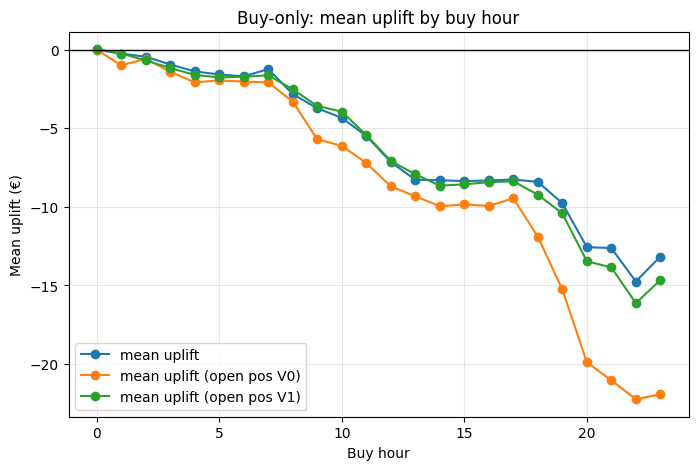

In [84]:
def compute_buy_only_stats(df):
    buy_only = df[(df["kind"] == "buy_only")  | (df["kind"] == "no_da")]  #& (df["combo_id"] != 0)]

    stats = (
        buy_only
        .groupby("buy_hour")["uplift_abs"]
        .agg(
            mean="mean",
            median="median",
            success_rate=lambda x: (x > 0).mean(),
            count="count",
        )
        .reset_index()
    )
    return stats

stats_df = compute_buy_only_stats(df)
stats_df_open_pos_V0 = compute_buy_only_stats(df_open_pos_V0)
stats_df_open_pos_V1 = compute_buy_only_stats(df_open_pos_V1)



plt.figure(figsize=(8, 5))
plt.plot(
    stats_df["buy_hour"],
    stats_df["mean"],
    label="mean uplift",
    marker="o"
)

plt.plot(
    stats_df_open_pos_V0["buy_hour"],
    stats_df_open_pos_V0["mean"],
    label="mean uplift (open pos V0)",
    marker="o"
)

plt.plot(
    stats_df_open_pos_V1["buy_hour"],
    stats_df_open_pos_V1["mean"],
    label="mean uplift (open pos V1)",
    marker="o"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Buy-only: mean uplift by buy hour")
plt.xlabel("Buy hour")
plt.ylabel("Mean uplift (€)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()



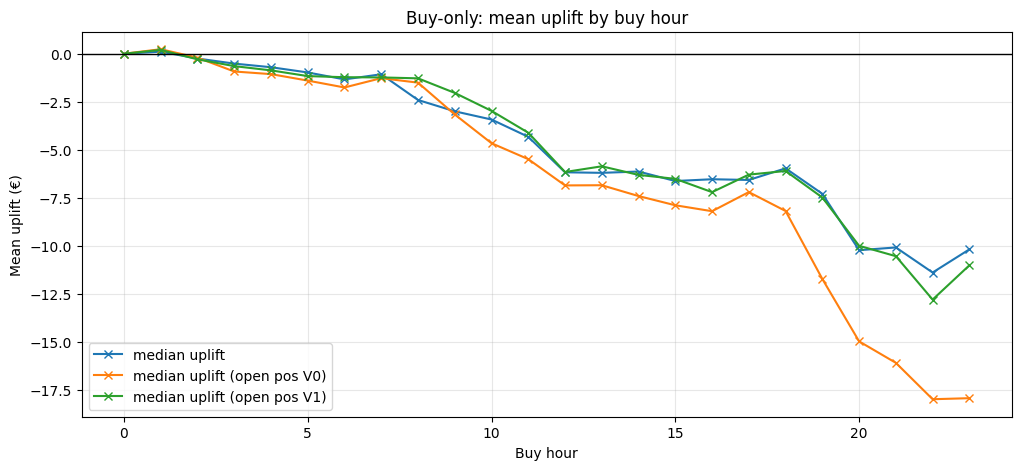

In [86]:
def compute_buy_only_stats(df):
    buy_only = df[(df["kind"] == "buy_only")  | (df["kind"] == "no_da")]  #& (df["combo_id"] != 0)]

    stats = (
        buy_only
        .groupby("buy_hour")["uplift_abs"]
        .agg(
            mean="mean",
            median="median",
            success_rate=lambda x: (x > 0).mean(),
            count="count",
        )
        .reset_index()
    )
    return stats

stats_df = compute_buy_only_stats(df)
stats_df_open_pos_V0 = compute_buy_only_stats(df_open_pos_V0)
stats_df_open_pos_V1 = compute_buy_only_stats(df_open_pos_V1)


plt.figure(figsize=(12, 5))
"""
plt.plot(stats_df["buy_hour"],stats_df["mean"],label="mean uplift", marker="o")
plt.plot(stats_df_open_pos["buy_hour"],stats_df_open_pos["mean"],label="mean uplift (open pos)", marker="o")
plt.plot(stats_df_open_pos_V2["buy_hour"],stats_df_open_pos_V2["mean"],label="mean uplift (open pos V2)", marker="o")
"""

plt.plot(stats_df["buy_hour"],stats_df["median"],label="median uplift",marker="x")

plt.plot(stats_df_open_pos_V0["buy_hour"],stats_df_open_pos_V0["median"],label="median uplift (open pos V0)",marker="x")

plt.plot(stats_df_open_pos_V1["buy_hour"],stats_df_open_pos_V1["median"],label="median uplift (open pos V1)",marker="x")

plt.axhline(0, color="black", linewidth=1)
plt.title("Buy-only: mean uplift by buy hour")
plt.xlabel("Buy hour")
plt.ylabel("Mean uplift (€)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

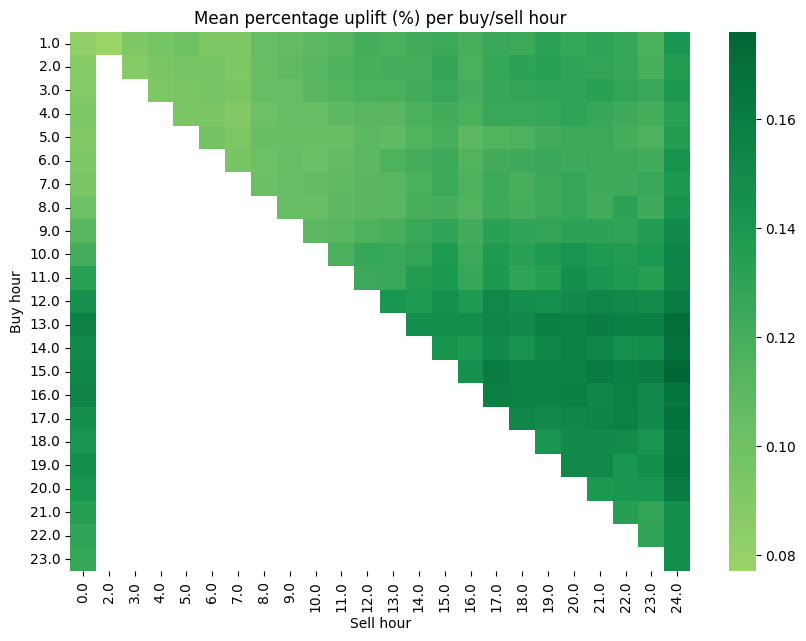

In [180]:
heat_mean = df[
    (df["combo_id"] != 0) & (df["uplift_pct"] > 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean percentage uplift (%) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()

In [ ]:
summary.dtypes

number_of_days                 datetime64[ns]
RI_base                               float64
combinations_max                      float64
combinations_max_pct                  float64
n_better_than_base                    float64
mean_uplift                           float64
median_uplift                         float64
mean_uplift_pct_if_better             float64
median_uplift_pct_if_better           float64
dtype: object

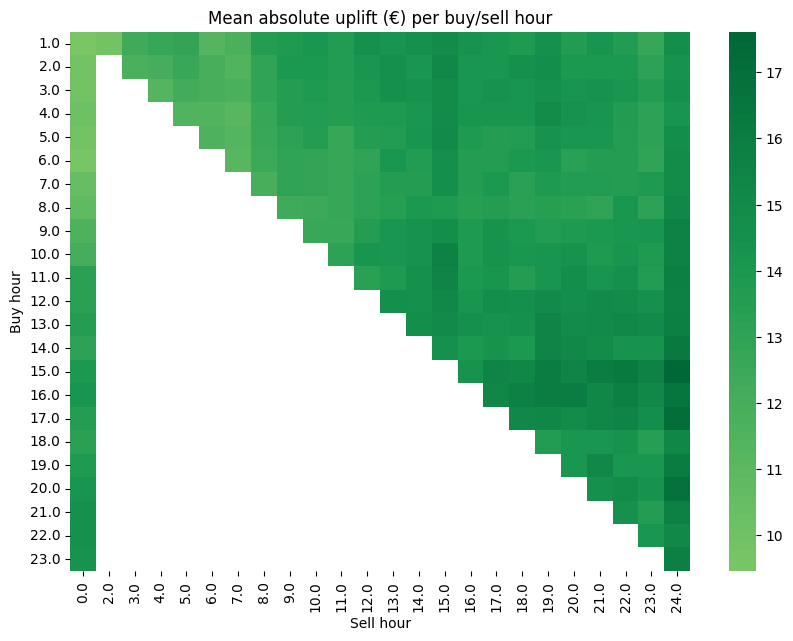

In [181]:
heat_mean = df[
    (df["combo_id"] != 0) & (df["uplift_abs"] > 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_abs",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean absolute uplift (€) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()


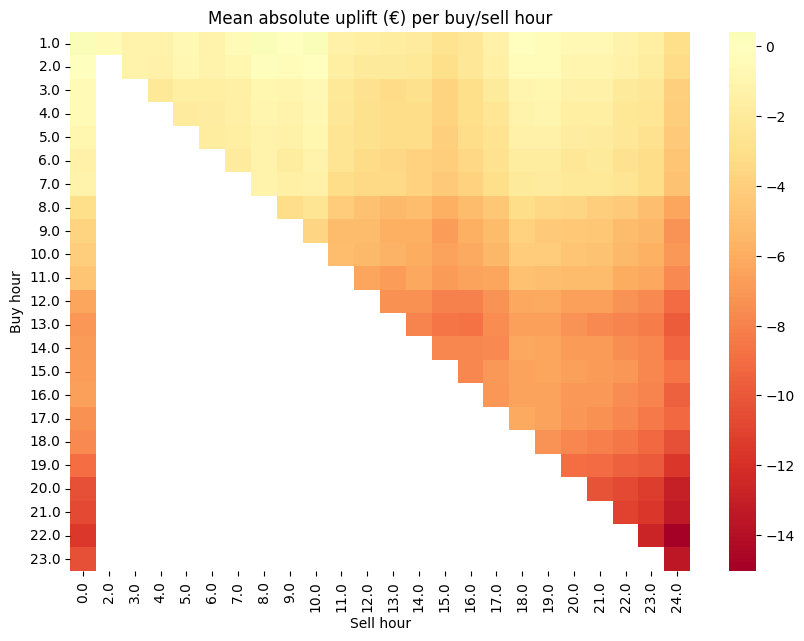

In [182]:
heat_mean = df[
    (df["combo_id"] != 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_abs",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean absolute uplift (€) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()

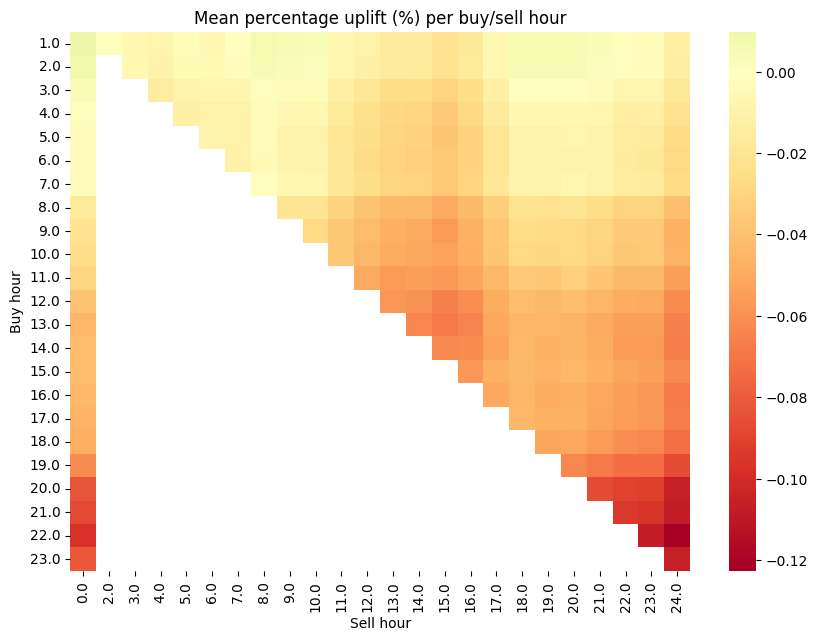

In [183]:
heat_mean = df[
    (df["combo_id"] != 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean percentage uplift (%) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()

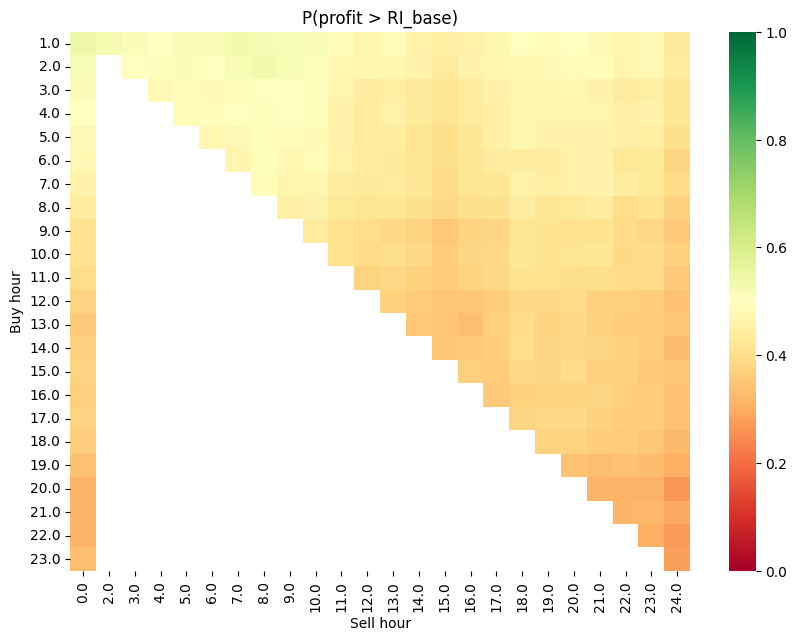

In [184]:
heat_freq = df[df["combo_id"] != 0].assign(
    better=lambda x: x["uplift_abs"] > 0
).pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="better",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_freq, vmin=0, vmax=1,cmap="RdYlGn") #cmap="viridis")
plt.title("P(profit > RI_base)")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()


In [188]:
df["holding_time"] = df["sell_hour"] - df["buy_hour"]

df.groupby("holding_time")["uplift_abs"].agg(
    mean="mean",
    median="median",
    count="count"
).reset_index()


,holding_time,mean,median,count
0,-23.0,-10.437948,-7.488497,1461
1,-22.0,-11.494388,-8.057925,1461
2,-21.0,-10.704031,-7.339240,1461
3,-20.0,-10.381671,-7.415568,1461
4,-19.0,-8.958306,-6.242372,1461
5,-18.0,-7.635493,-4.933411,1461
6,-17.0,-7.316044,-4.666763,1461
7,-16.0,-6.680144,-4.533833,1461
8,-15.0,-6.764407,-4.760924,1461
9,-14.0,-6.827236,-4.675484,1461


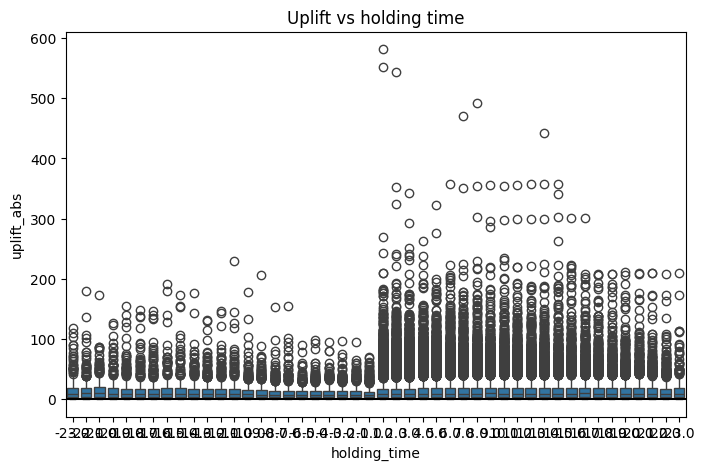

In [189]:
plt.figure(figsize=(8,5))
sns.boxplot(x="holding_time", y="uplift_abs", data=df[df["uplift_abs"]>0])
plt.axhline(0, color="black")
plt.title("Uplift vs holding time")
plt.show()

In [190]:
df.groupby("buy_hour")["uplift_abs"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count"
)

,mean,median,success_rate,count
buy_hour,,,,
0.0,0.000000,0.000000,0.000000,1461
1.0,-1.041730,-0.192468,0.493127,35064
2.0,-1.280474,-0.376827,0.486385,33603
3.0,-1.962273,-1.045869,0.465279,32142
4.0,-2.074591,-1.062877,0.464881,30681
5.0,-2.253910,-1.358240,0.453901,29220
6.0,-2.600648,-1.754681,0.443820,27759
7.0,-2.719590,-1.786674,0.440794,26298
8.0,-4.352417,-2.736125,0.419254,24837


In [191]:
df.groupby("sell_hour")["uplift_abs"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count"
)


,mean,median,success_rate,count
sell_hour,,,,
0.0,-5.014924,-2.106581,0.389231,35064
2.0,-0.552606,0.707413,0.529090,1461
3.0,-1.186372,0.113388,0.506502,2922
4.0,-1.638976,-0.219441,0.491216,4383
5.0,-1.269989,0.049395,0.502738,5844
6.0,-1.519257,-0.183243,0.492950,7305
7.0,-1.309419,-0.060501,0.497376,8766
8.0,-0.779238,0.232738,0.507285,10227
9.0,-1.324918,-0.300803,0.490418,11688


In [192]:
q = df["uplift_abs"].quantile(0.95)
top = df[df["uplift_abs"] >= q]

top.groupby(["buy_hour", "sell_hour"]).size().sort_values(ascending=False)

buy_hour  sell_hour
2.0       14.0         100
4.0       21.0          97
2.0       18.0          97
1.0       12.0          95
2.0       13.0          94
                      ... 
4.0       0.0           42
8.0       0.0           41
5.0       0.0           39
1.0       0.0           39
6.0       0.0           38
Length: 299, dtype: int64

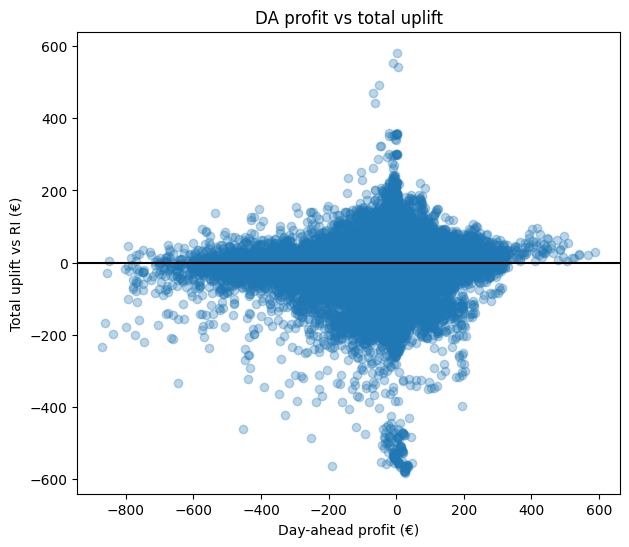

In [193]:
plt.figure(figsize=(7,6))
plt.scatter(df["da_profit"], df["uplift_abs"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Day-ahead profit (€)")
plt.ylabel("Total uplift vs RI (€)")
plt.title("DA profit vs total uplift")
plt.show()


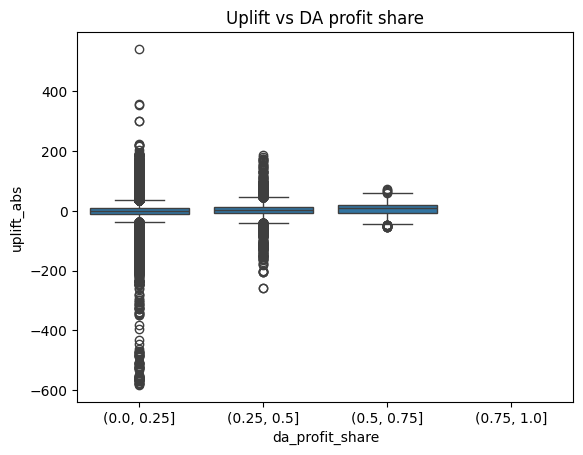

In [194]:
sns.boxplot(x=pd.cut(df["da_profit_share"], bins=[0,0.25,0.5,0.75,1]),
            y=df["uplift_abs"])
plt.title("Uplift vs DA profit share")
plt.show()


In [195]:
g = (df[df.combo_id != 0]
     .groupby(["buy_hour","sell_hour"])
     .apply(lambda x: pd.Series({
         "success_rate": (x.uplift_abs > 0).mean(),
         "mean": x.uplift_abs.mean(),
         "p05": x.uplift_abs.quantile(0.05),
         "p25": x.uplift_abs.quantile(0.25),
         "p50": x.uplift_abs.quantile(0.5),
         "p75": x.uplift_abs.quantile(0.75),
         "p95": x.uplift_abs.quantile(0.95),
         "p99": x.uplift_abs.quantile(0.99),
         "n": len(x),
     }))
     .reset_index())

pairs = g.to_dict("records")
pareto = []
for i,a in enumerate(pairs):
    dominated = False
    for j,b in enumerate(pairs):
        if i==j: 
            continue
        if (b["success_rate"] >= a["success_rate"] and b["p95"] >= a["p95"]
            and (b["success_rate"] > a["success_rate"] or b["p95"] > a["p95"])):
            dominated = True
            break
    if not dominated:
        pareto.append(a)
pareto_df = pd.DataFrame(pareto).sort_values(["success_rate","p95"], ascending=False)

pareto_df



/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_38790/1323279721.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,buy_hour,sell_hour,success_rate,mean,p05,p25,p50,p75,p95,p99,n
0,1.0,0.0,0.542779,0.337927,-21.157047,-5.137958,0.789224,7.009161,22.466144,40.475196,1461.0
3,2.0,8.0,0.534565,-0.126374,-28.235032,-6.568232,0.841344,9.447518,30.709638,56.202032,1461.0
1,1.0,8.0,0.526352,0.325895,-26.191751,-6.437137,0.838428,9.617770,31.790085,55.020002,1461.0
2,1.0,10.0,0.519507,0.419150,-27.203826,-7.543784,0.599648,9.722246,32.358205,66.497621,1461.0
4,2.0,10.0,0.509925,-0.100708,-29.276126,-7.959188,0.293263,9.373694,32.422813,68.729835,1461.0
5,2.0,13.0,0.472279,-1.994826,-33.451690,-10.930222,-0.872409,8.844467,34.136962,66.379782,1461.0


In [196]:
syn = df[df.combo_id != 0].copy()

topk = (syn.sort_values(["day","uplift_abs"], ascending=[True, False])
          .groupby("day")
          .head(5))

counts = (topk.groupby(["buy_hour","sell_hour"])
              .size()
              .sort_values(ascending=False)
              .head(20))
counts


buy_hour  sell_hour
1.0       9.0          63
          5.0          58
          3.0          57
          4.0          56
          8.0          56
          10.0         53
7.0       9.0          52
1.0       6.0          50
2.0       8.0          50
1.0       2.0          50
          7.0          49
2.0       10.0         49
          9.0          46
3.0       8.0          42
          6.0          42
1.0       18.0         42
          0.0          41
2.0       4.0          41
23.0      0.0          41
5.0       9.0          41
dtype: int64

In [197]:
def cvar(x, alpha=0.1):
    q = x.quantile(alpha)
    return x[x <= q].mean()

risk = (syn.groupby(["buy_hour","sell_hour"])["uplift_abs"]
          .apply(lambda x: pd.Series({
              "mean": x.mean(),
              "cvar10": cvar(x, 0.1),
              "p95": x.quantile(0.95),
              "success": (x>0).mean(),
          }))
          .reset_index())
risk

,buy_hour,sell_hour,level_2,uplift_abs
0,1.0,0.0,mean,0.337927
1,1.0,0.0,cvar10,-30.292450
2,1.0,0.0,p95,22.466144
3,1.0,0.0,success,0.542779
4,1.0,2.0,mean,-0.552606
...,...,...,...,...
1191,23.0,0.0,success,0.333333
1192,23.0,24.0,mean,-13.483502
1193,23.0,24.0,cvar10,-74.615409
1194,23.0,24.0,p95,26.042892


In [198]:
df.sort_values("uplift_pct", ascending=False).head(50)

,day,combo_id,kind,buy_hour,sell_hour,profit,da_exec_time,da_profit,da_buy_price,da_sell_price,da_profit_share,RI_base,uplift_abs,uplift_pct,holding_time
66567,2019-08-09 00:00:00+00:00,267,buy_sell,16.0,20.0,211.047927,2019-08-09 13:00:00,67.5980,-44.98,26.30,0.32,24.812314,186.235613,7.505774,4.0
66565,2019-08-09 00:00:00+00:00,265,buy_sell,16.0,18.0,211.008447,2019-08-09 13:00:00,44.9628,-44.98,-0.02,0.21,24.812314,186.196133,7.504183,2.0
66564,2019-08-09 00:00:00+00:00,264,buy_sell,16.0,17.0,205.348852,2019-08-09 13:00:00,28.4508,-44.98,-19.22,0.14,24.812314,180.536538,7.276086,1.0
66559,2019-08-09 00:00:00+00:00,259,buy_sell,15.0,20.0,204.373341,2019-08-09 13:00:00,72.2380,-49.62,26.30,0.35,24.812314,179.561027,7.236771,5.0
66316,2019-08-09 00:00:00+00:00,16,buy_only,16.0,0.0,204.244669,2019-08-09 13:00:00,44.9800,-44.98,NaN,0.22,24.812314,179.432355,7.231585,-16.0
66568,2019-08-09 00:00:00+00:00,268,buy_sell,16.0,21.0,200.124950,2019-08-09 13:00:00,68.9740,-44.98,27.90,0.34,24.812314,175.312637,7.065550,5.0
66557,2019-08-09 00:00:00+00:00,257,buy_sell,15.0,18.0,197.848069,2019-08-09 13:00:00,49.6028,-49.62,-0.02,0.25,24.812314,173.035756,6.973786,3.0
66571,2019-08-09 00:00:00+00:00,271,buy_sell,16.0,24.0,197.777887,2019-08-09 13:00:00,69.7824,-44.98,28.84,0.35,24.812314,172.965573,6.970957,8.0
66570,2019-08-09 00:00:00+00:00,270,buy_sell,16.0,23.0,197.761997,2019-08-09 13:00:00,72.3538,-44.98,31.83,0.37,24.812314,172.949683,6.970317,7.0
66315,2019-08-09 00:00:00+00:00,15,buy_only,15.0,0.0,197.570083,2019-08-09 13:00:00,49.6200,-49.62,NaN,0.25,24.812314,172.757769,6.962582,-15.0


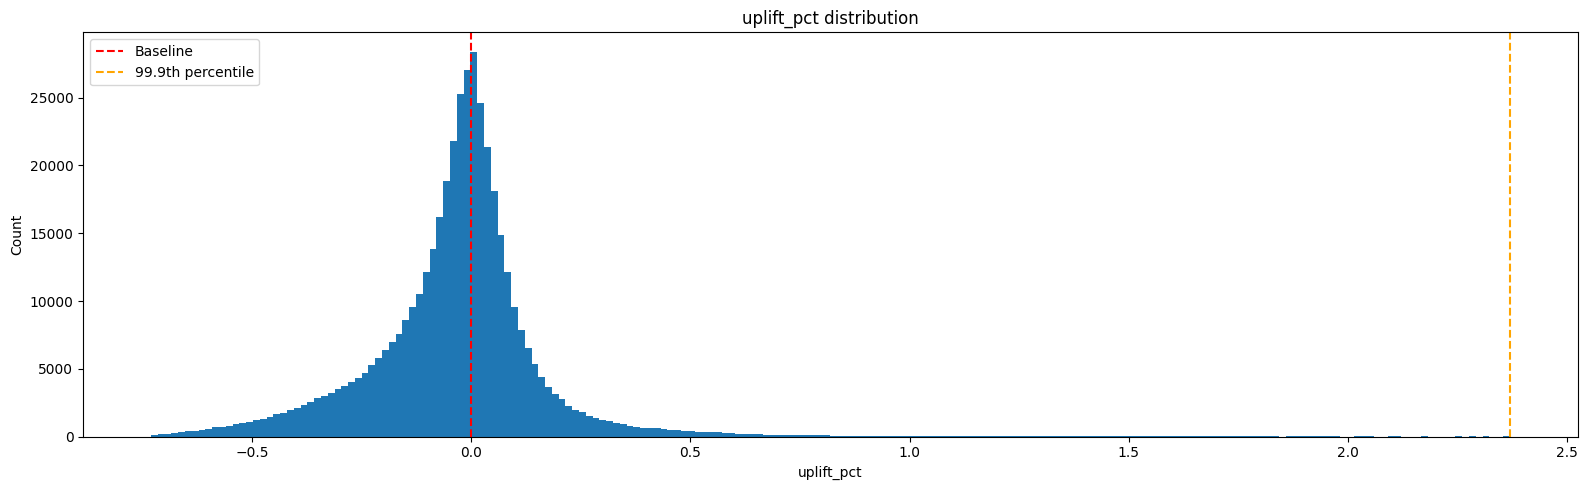

In [264]:
import matplotlib.pyplot as plt
import numpy as np

uplift = df["uplift_pct"].dropna()


q01 = uplift.quantile(0.001)
q99 = uplift.quantile(0.999)


plt.figure(figsize=(16, 5))
plt.hist(uplift[(uplift >= q01) & (uplift <= q99)], bins=200)
plt.axvline(0, color="red", linestyle="--", label="Baseline")
plt.axvline(q99, color="orange", linestyle="--", label="99.9th percentile")
plt.xlabel("uplift_pct")
plt.ylabel("Count")
plt.title("uplift_pct distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
summary.dtypes

number_of_days                 datetime64[ns]
RI_base                               float64
combinations_max                      float64
combinations_max_pct                  float64
n_better_than_base                    float64
mean_uplift                           float64
median_uplift                         float64
mean_uplift_pct_if_better             float64
median_uplift_pct_if_better           float64
dtype: object

In [200]:
df["date"] = df["day"].dt.date

<Figure size 2000x1000 with 0 Axes>

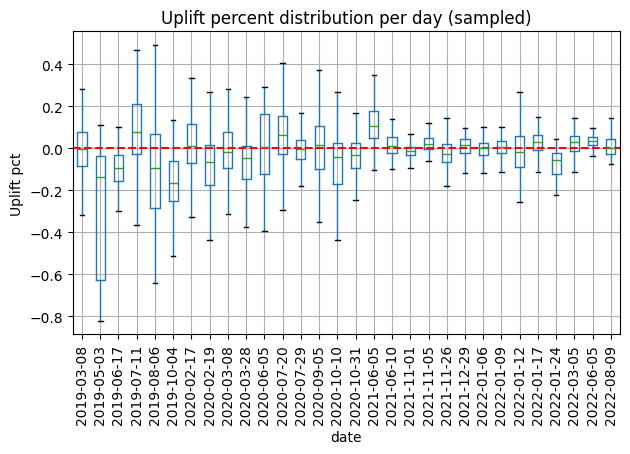

In [201]:
sample_days = df["date"].drop_duplicates().sample(n=30, random_state=42)
df_sample = df[df["date"].isin(sample_days)]

plt.figure(figsize=(20, 10))
df_sample.boxplot(
    column="uplift_pct",
    by="date",
    showfliers=False,
    rot=90
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Uplift percent distribution per day (sampled)")
plt.suptitle("")
plt.ylabel("Uplift pct")
plt.tight_layout()
plt.show()

<Figure size 2000x1000 with 0 Axes>

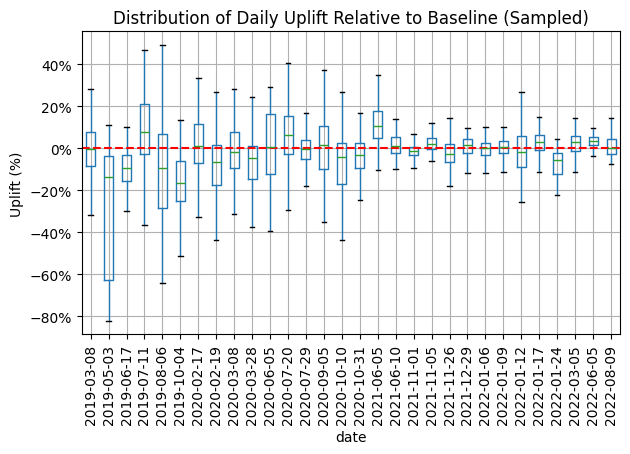

In [202]:
import matplotlib.ticker as mtick

sample_days = df["date"].drop_duplicates().sample(n=30, random_state=42)
df_sample = df[df["date"].isin(sample_days)]

plt.figure(figsize=(20, 10))
ax = df_sample.boxplot(
    column="uplift_pct",
    by="date",
    showfliers=False,
    rot=90
)

# Prozent-Achse für Werte im Bereich 0–1
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.axhline(0, color="red", linestyle="--")
plt.title("Distribution of Daily Uplift Relative to Baseline (Sampled)")
plt.suptitle("")
plt.ylabel("Uplift (%)")
plt.tight_layout()
plt.show()


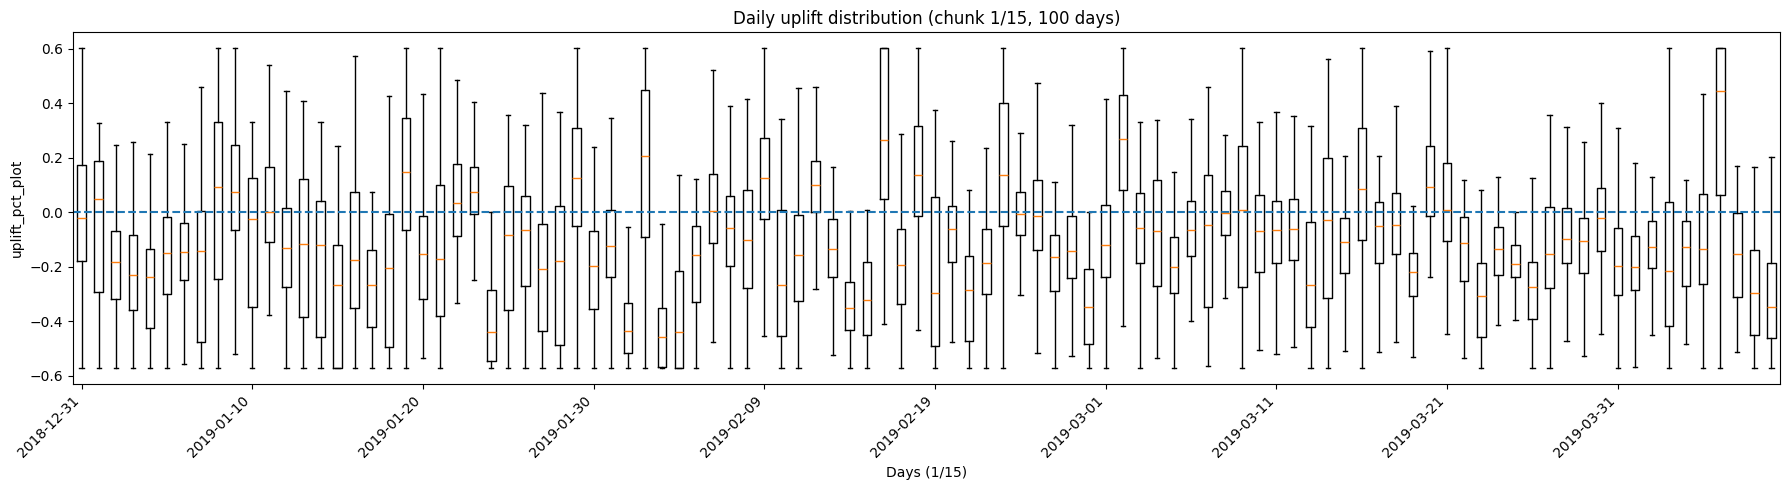

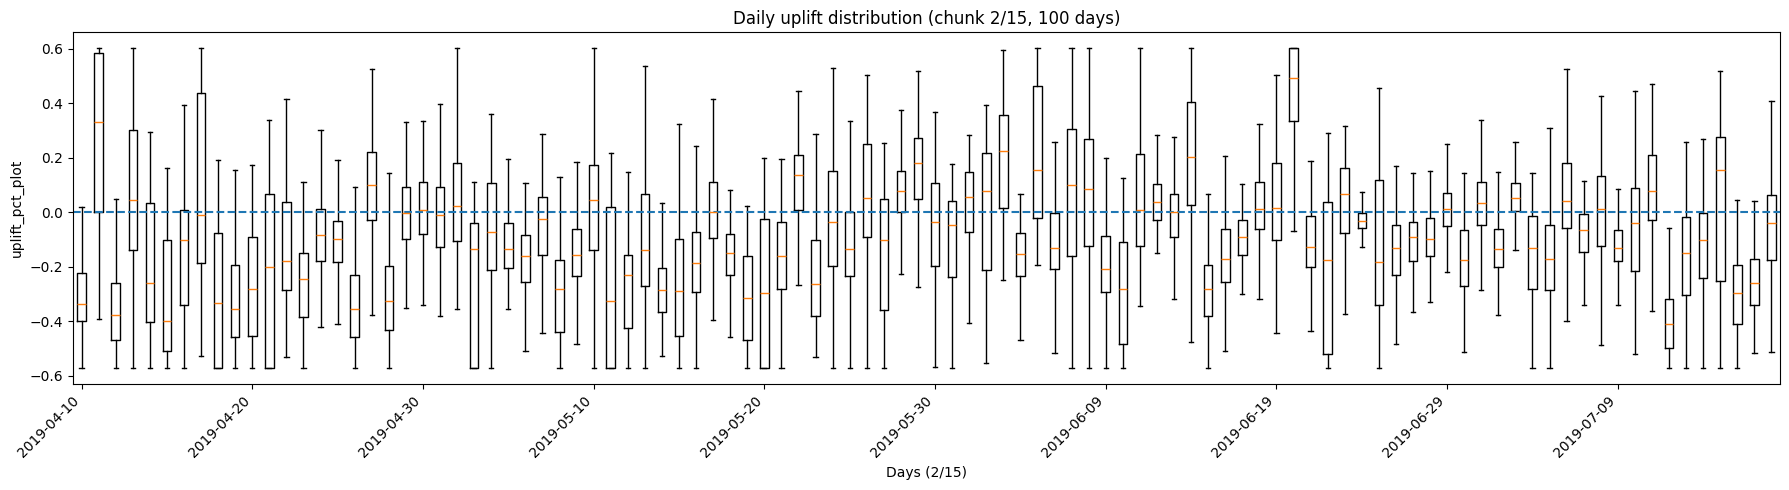

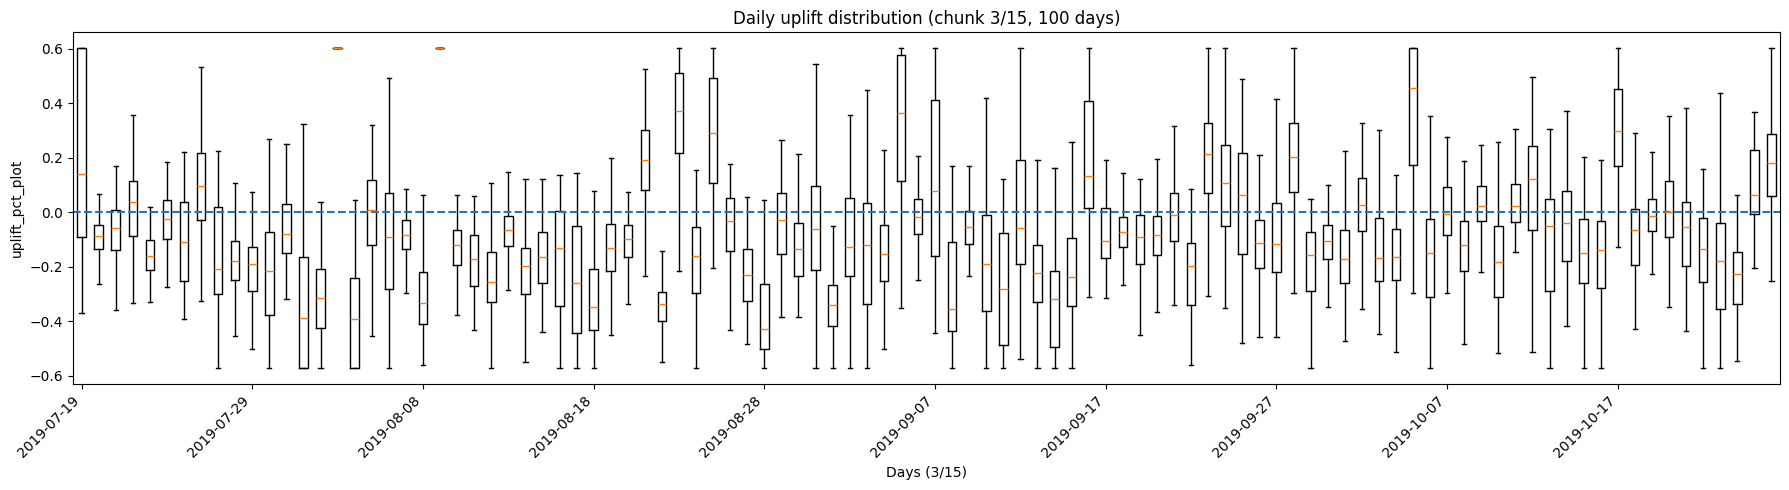

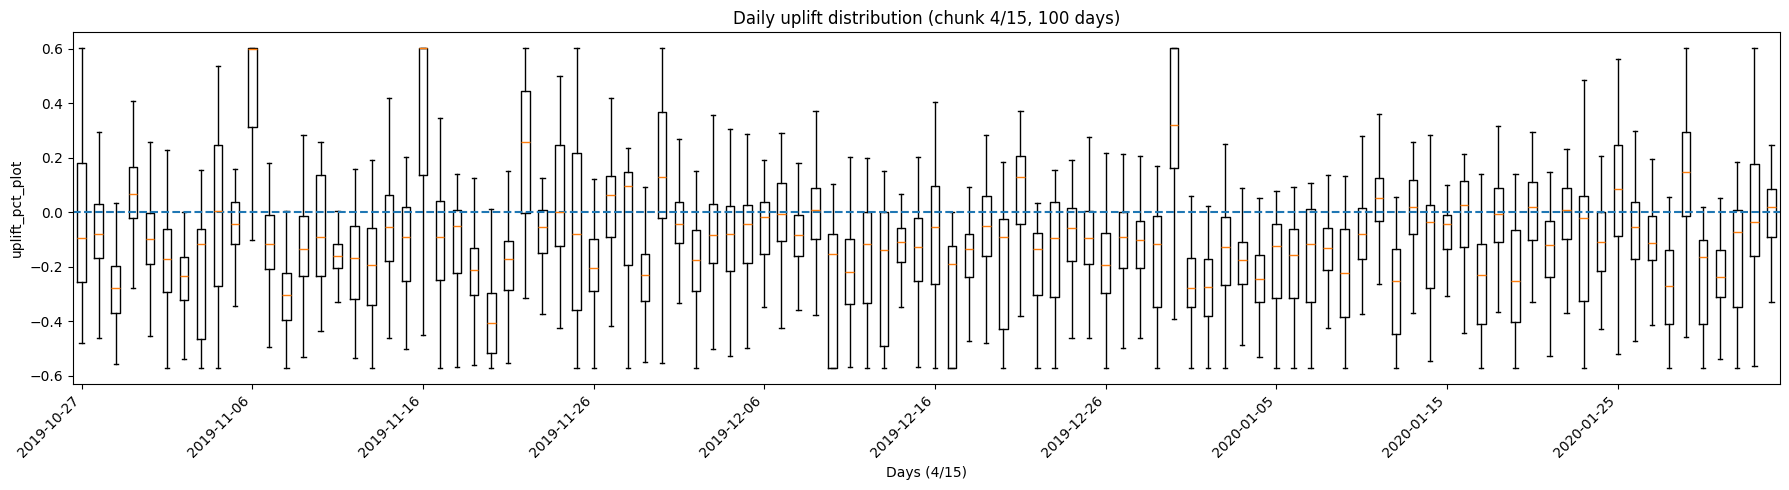

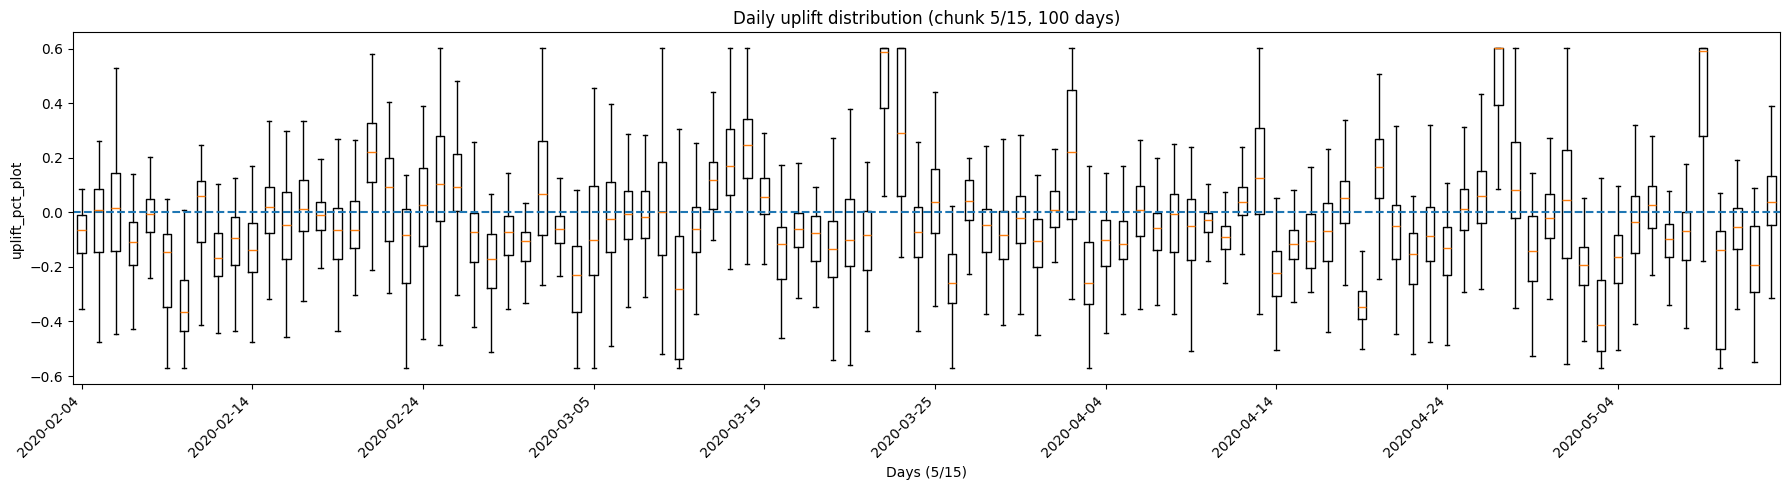

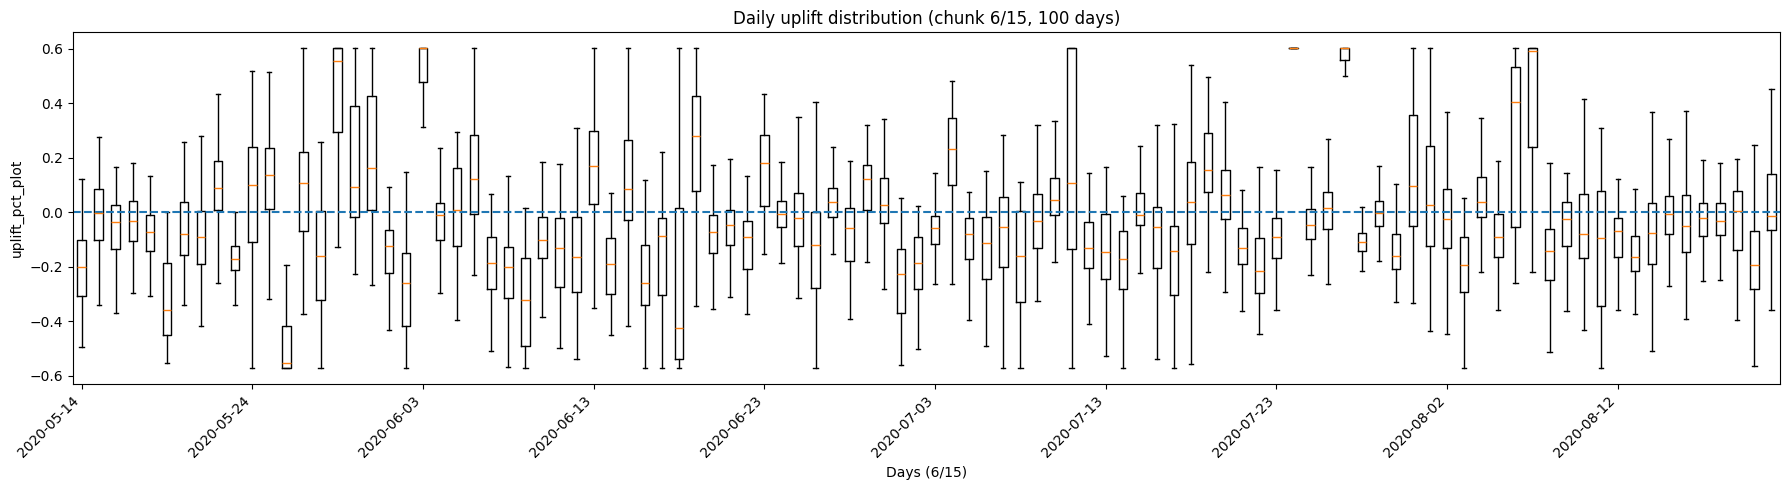

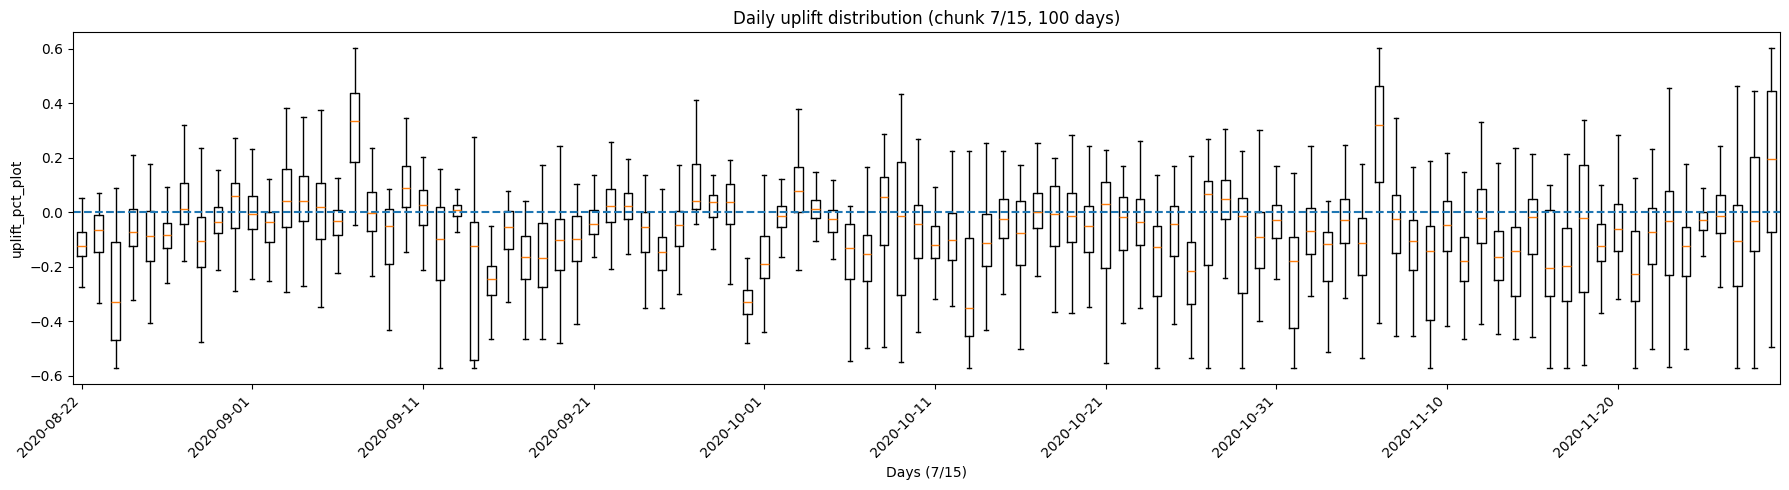

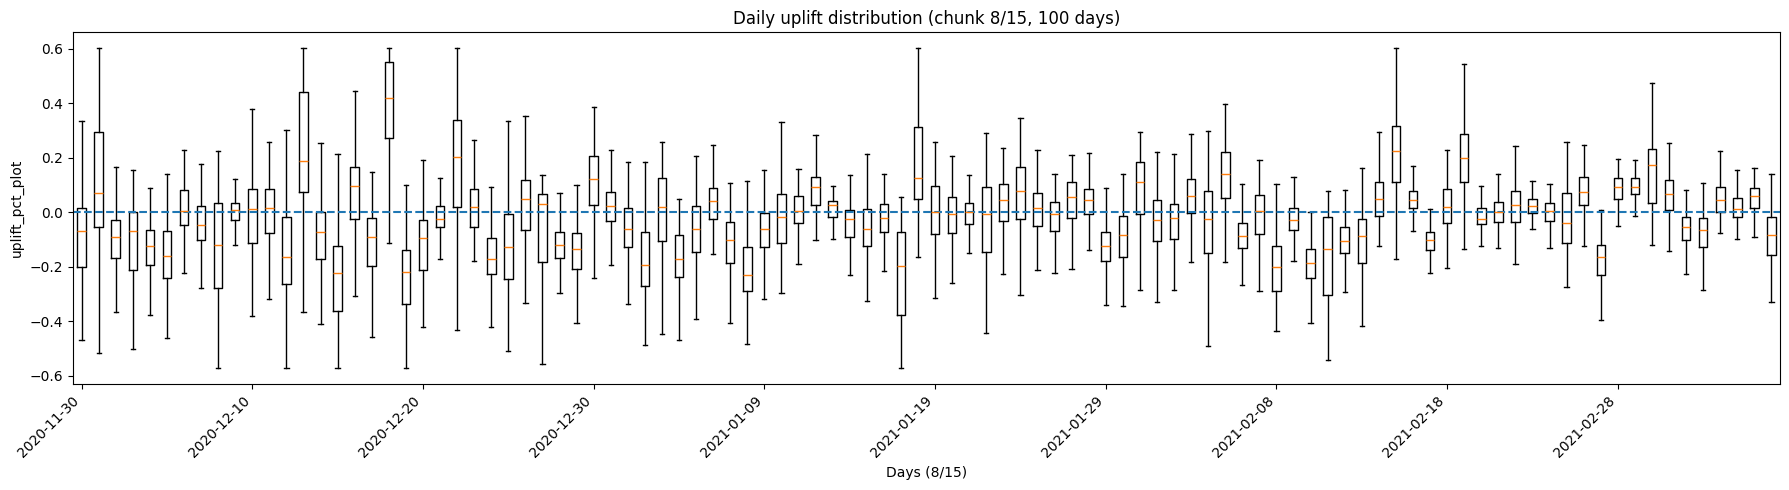

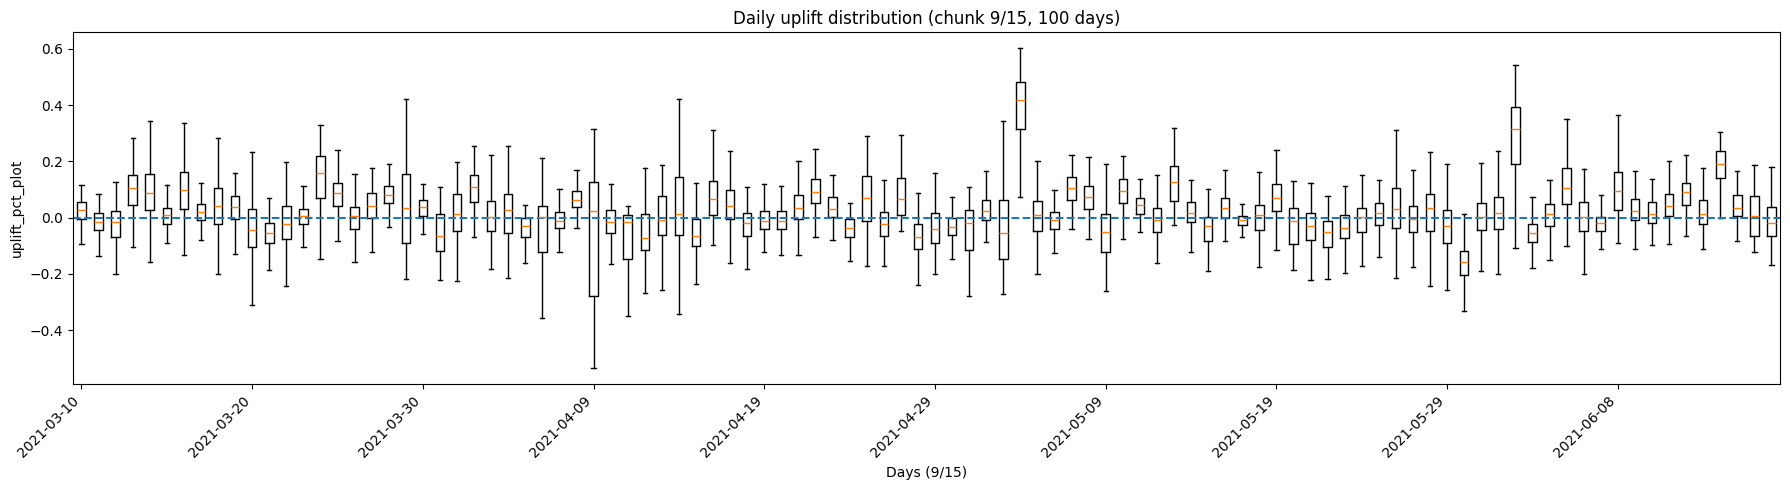

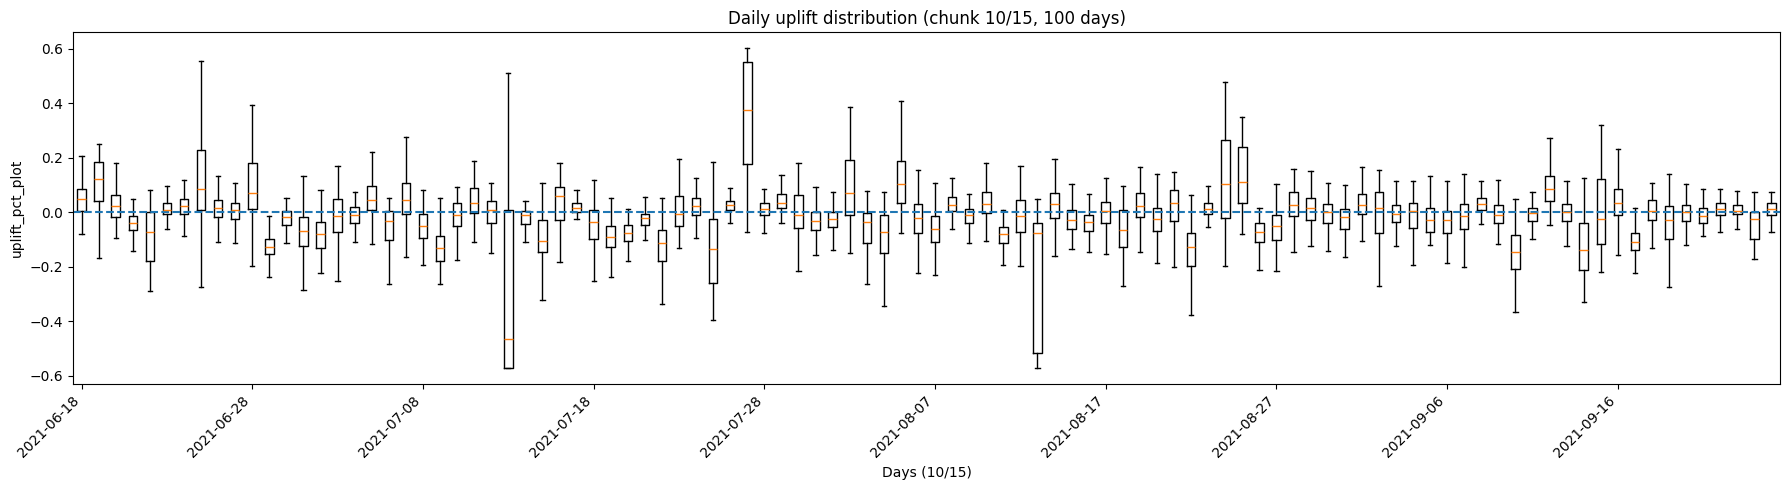

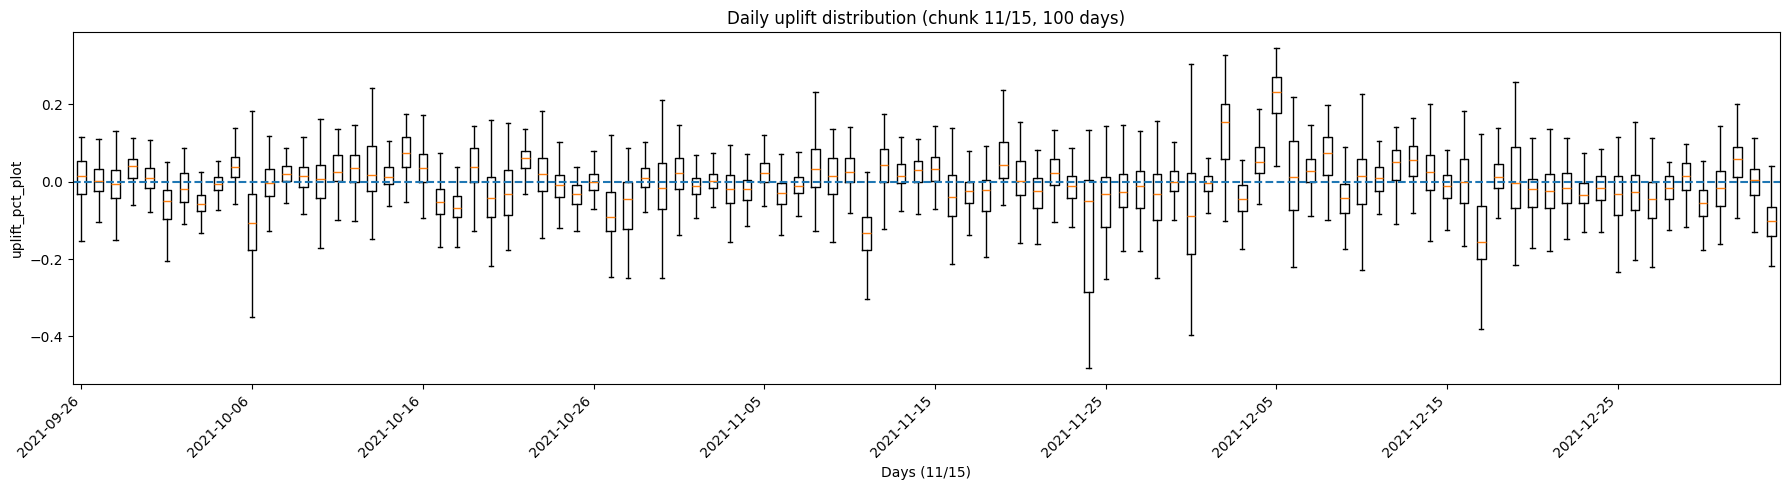

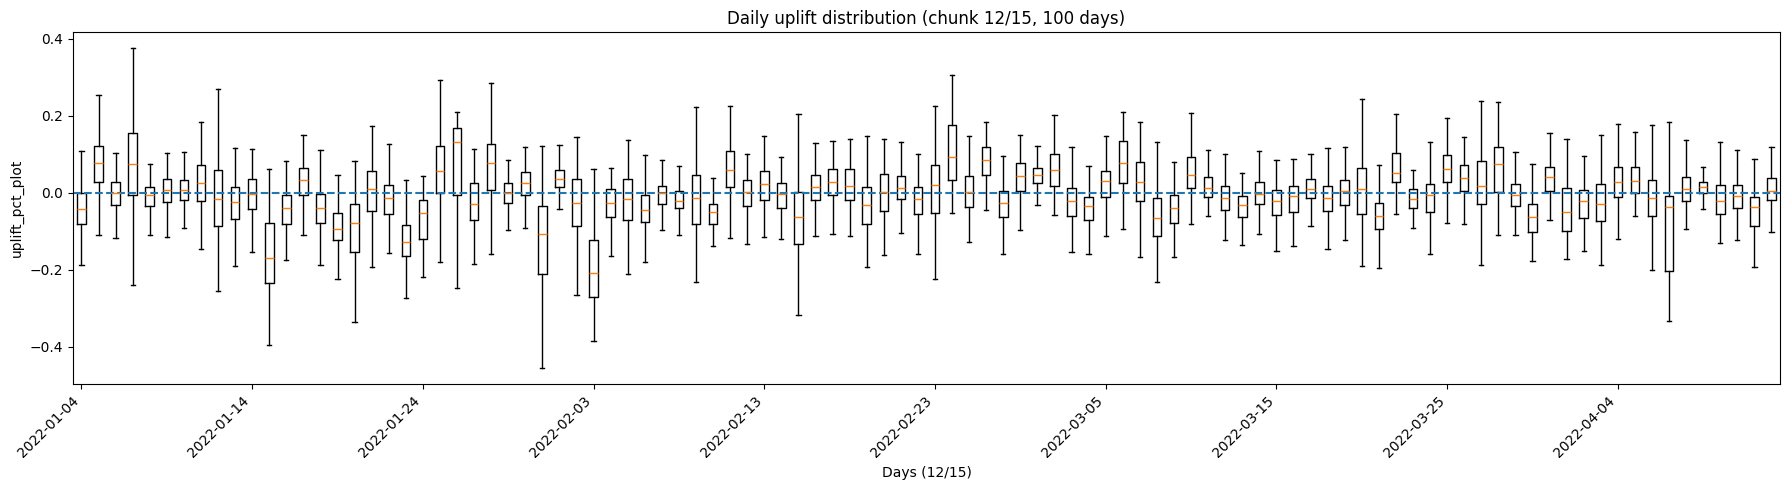

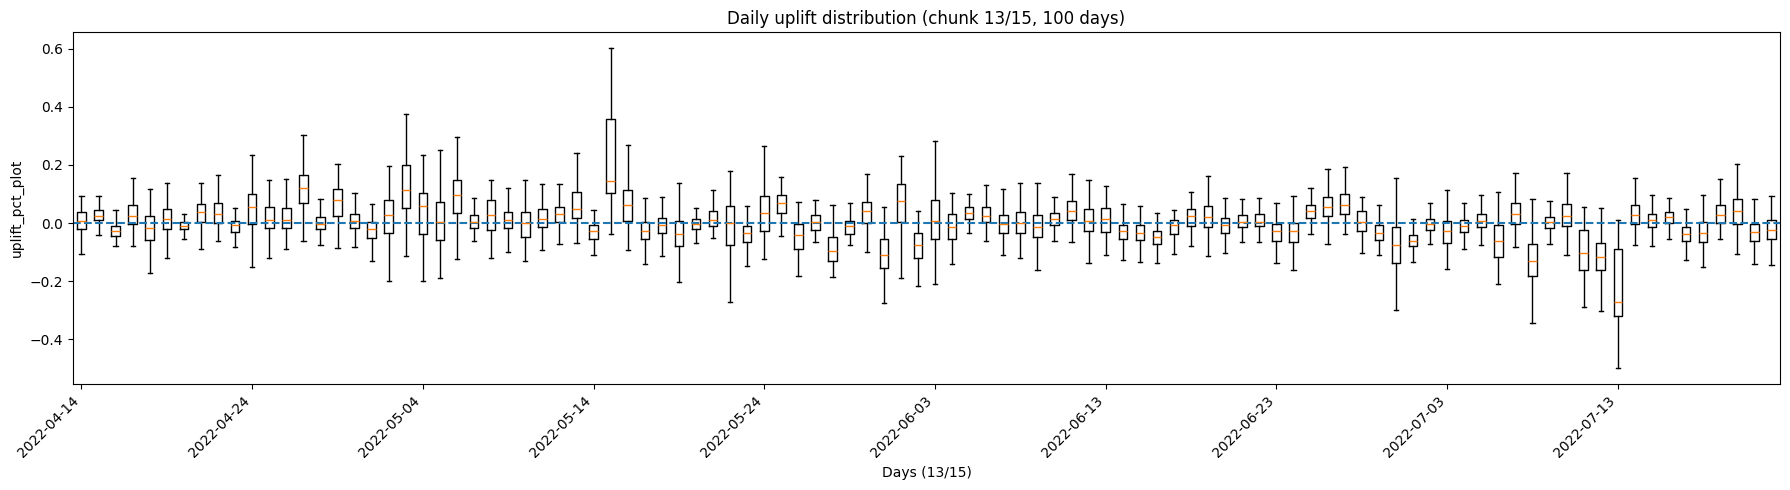

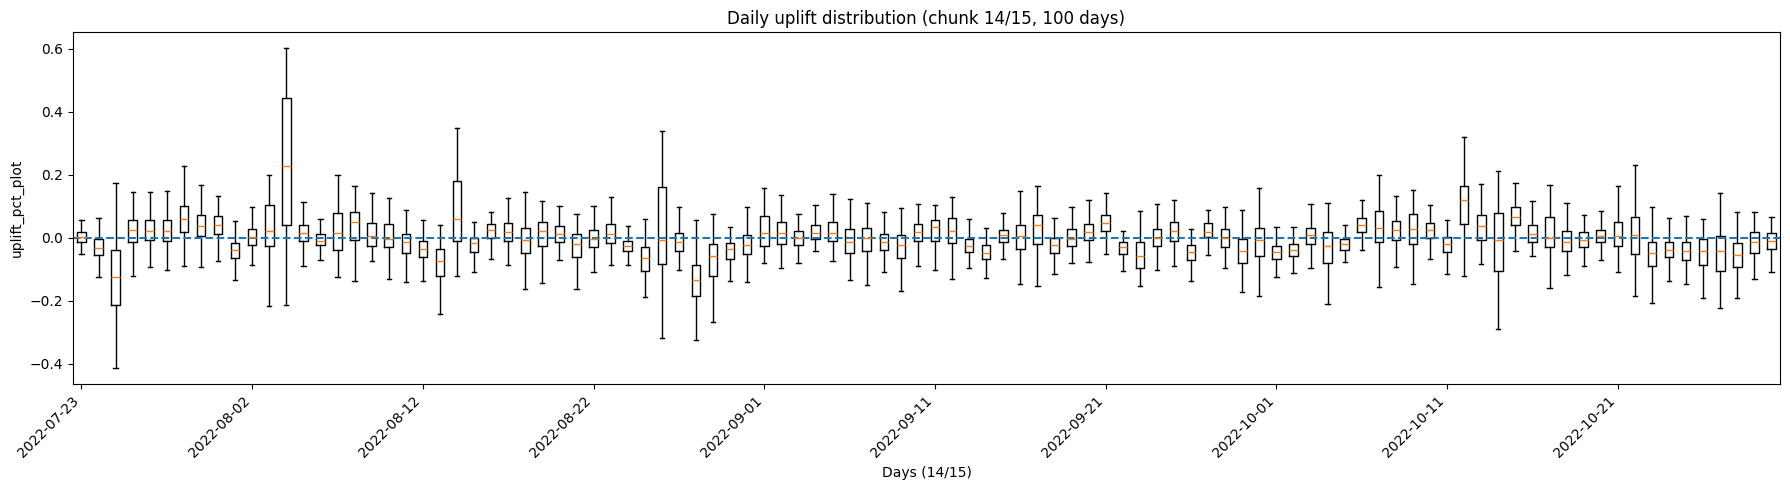

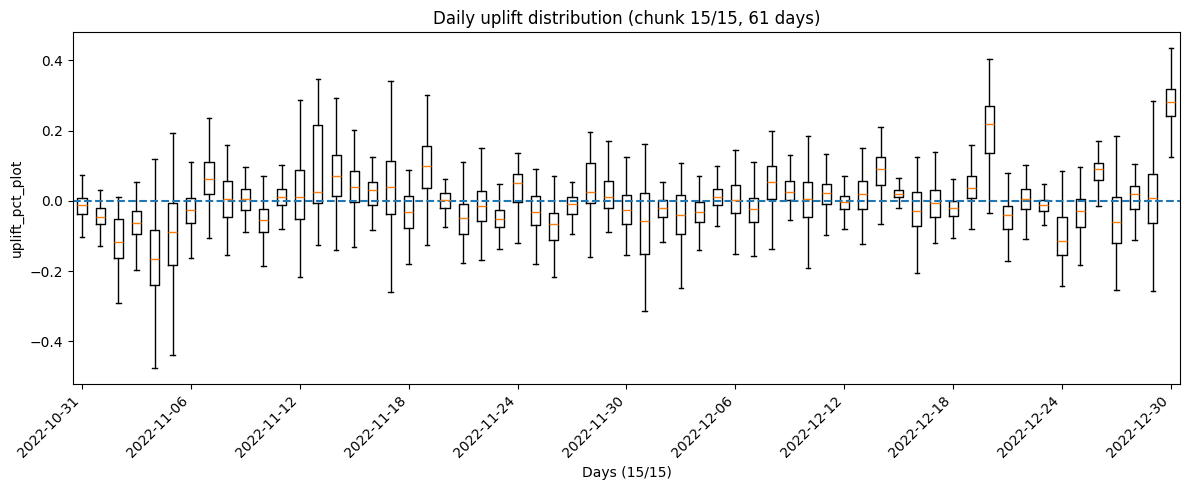

In [203]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_boxplots_by_day_chunks(
    df: pd.DataFrame,
    date_col: str = "date",
    value_col: str = "uplift_pct",
    chunk_size: int = 80,
    sort_days: str = "date",   # "date" oder "median" oder "mean"
    showfliers: bool = False,
):
    d = df[[date_col, value_col]].dropna().copy()

    # Liste aller Tage
    days = d[date_col].drop_duplicates()

    # Sortierung (optional hilfreich)
    if sort_days == "median":
        day_order = (d.groupby(date_col)[value_col].median()
                       .sort_values(ascending=True).index.tolist())
    elif sort_days == "mean":
        day_order = (d.groupby(date_col)[value_col].mean()
                       .sort_values(ascending=True).index.tolist())
    else:
        # nach Datum (sicher, wenn date echtes Date/Datetime ist)
        day_order = sorted(days.tolist())

    # Daten pro Tag einmal vorbereiten (spart Zeit)
    grouped = {day: d.loc[d[date_col] == day, value_col].values for day in day_order}

    n = len(day_order)
    n_chunks = int(np.ceil(n / chunk_size))

    for i in range(n_chunks):
        chunk_days = day_order[i*chunk_size:(i+1)*chunk_size]
        data = [grouped[day] for day in chunk_days]

        plt.figure(figsize=(max(12, len(chunk_days)*0.18), 5))
        plt.boxplot(data, showfliers=showfliers)

        # Baseline-Linie
        plt.axhline(0, linestyle="--")

        # X-Achse: nicht jeden Tag labeln (sonst zu voll)
        tick_step = max(1, len(chunk_days)//10)
        ticks = np.arange(1, len(chunk_days)+1, tick_step)
        labels = [str(chunk_days[t-1]) for t in ticks]

        plt.xticks(ticks, labels, rotation=45, ha="right")
        plt.xlabel(f"Days ({i+1}/{n_chunks})")
        plt.ylabel(value_col)
        plt.title(f"Daily uplift distribution (chunk {i+1}/{n_chunks}, {len(chunk_days)} days)")
        plt.tight_layout()
        plt.show()

q01, q99 = df["uplift_pct"].quantile([0.01, 0.99])
df["uplift_pct_plot"] = df["uplift_pct"].clip(q01, q99)
# Aufruf
plot_boxplots_by_day_chunks(
    df,
    date_col="date",
    value_col="uplift_pct_plot",
    chunk_size=100,
    sort_days="date",
    showfliers=False
)


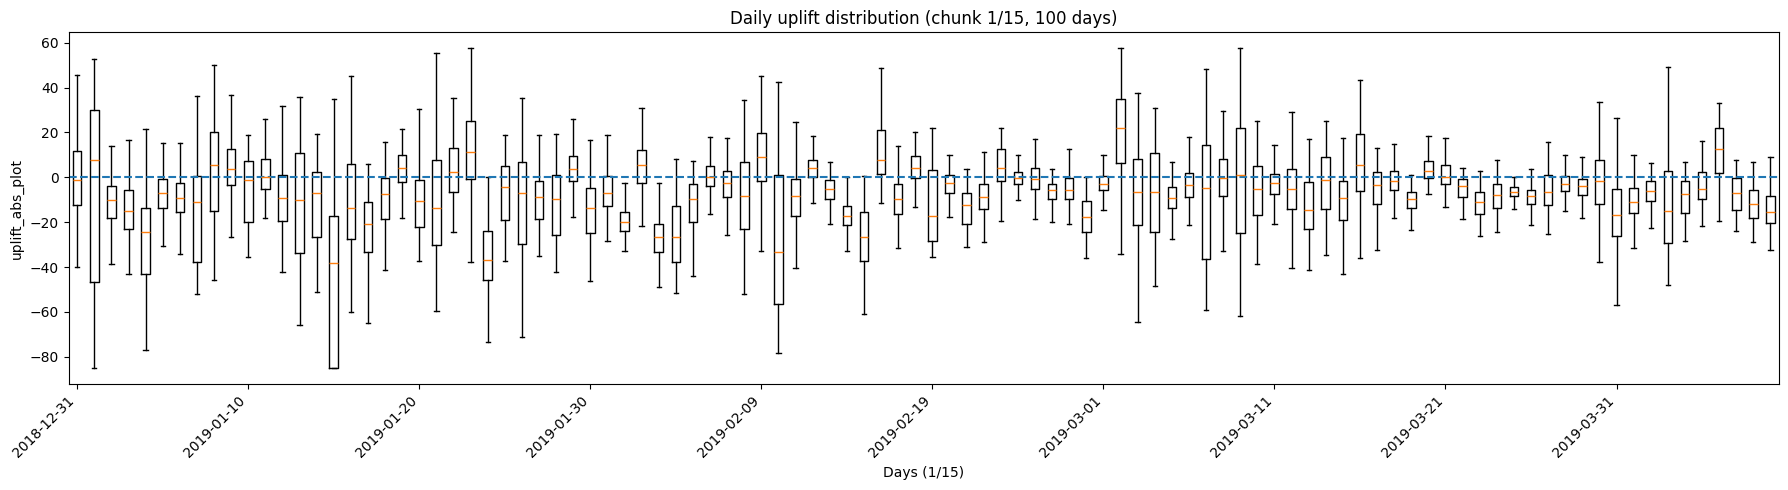

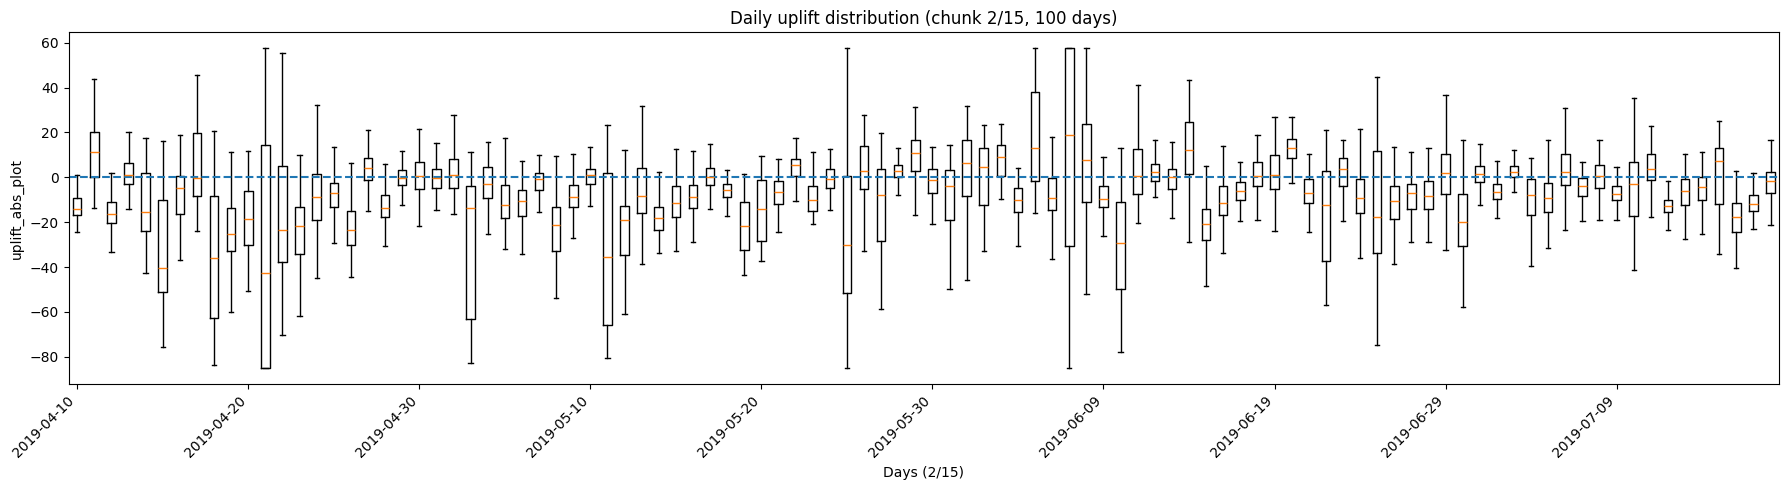

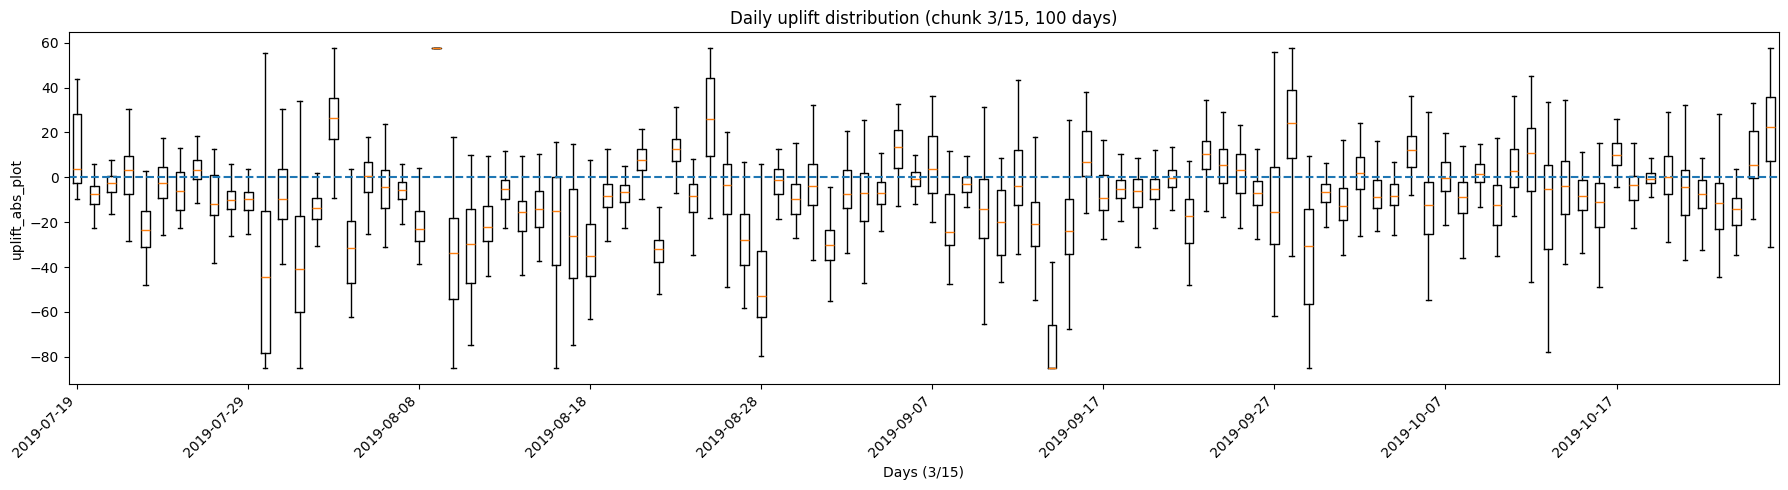

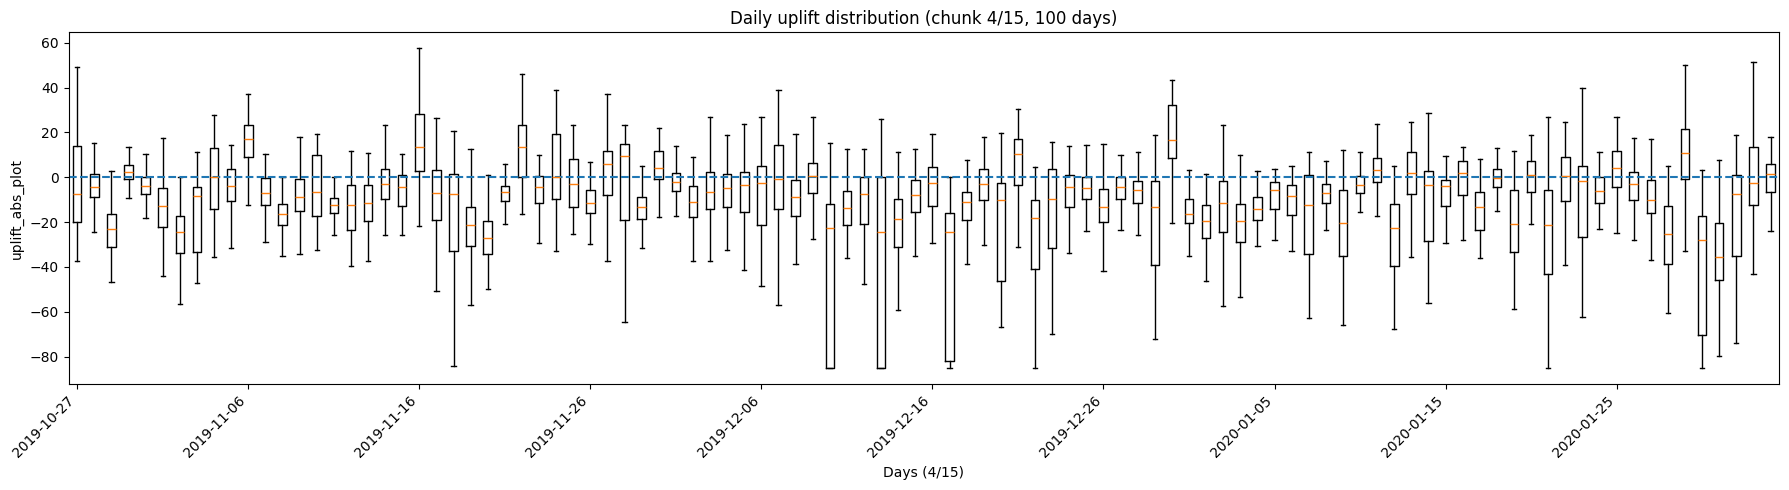

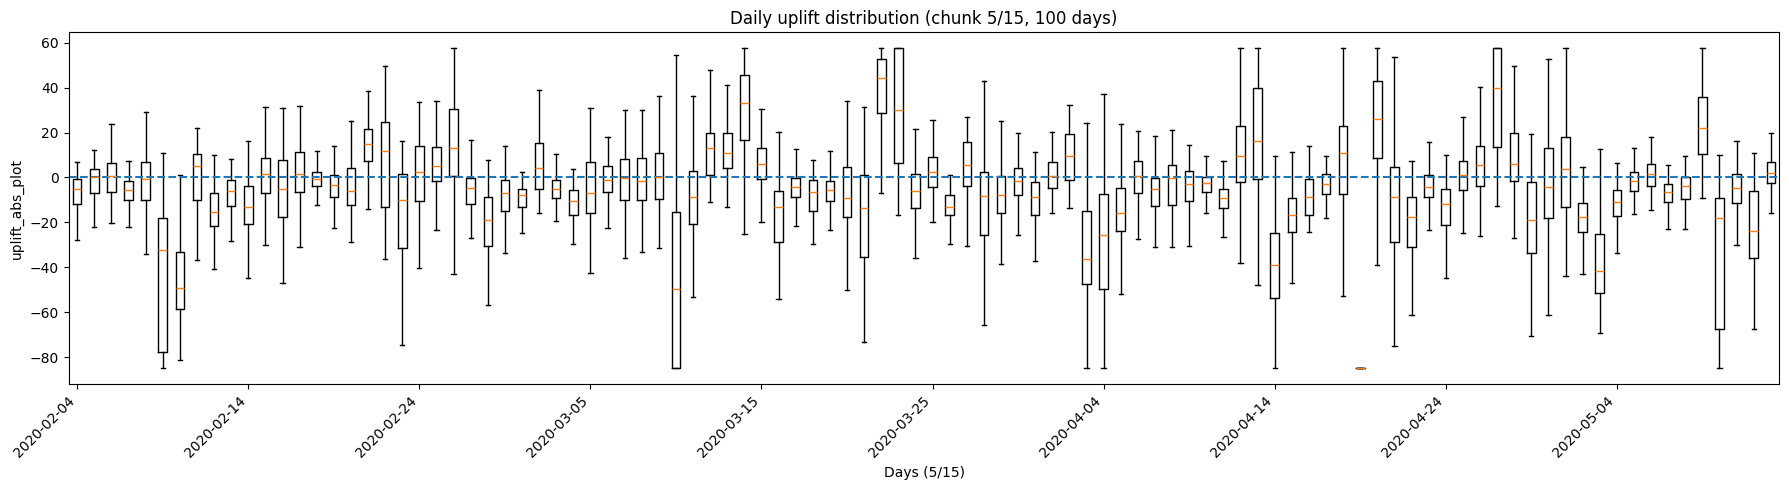

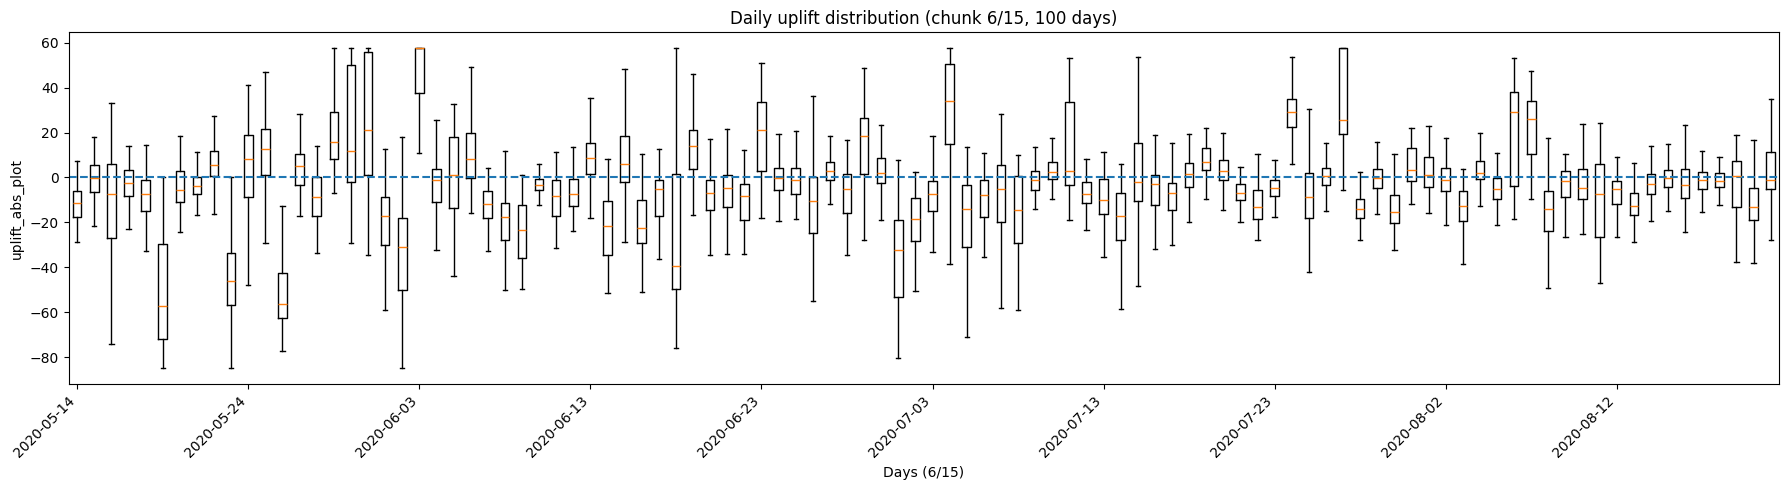

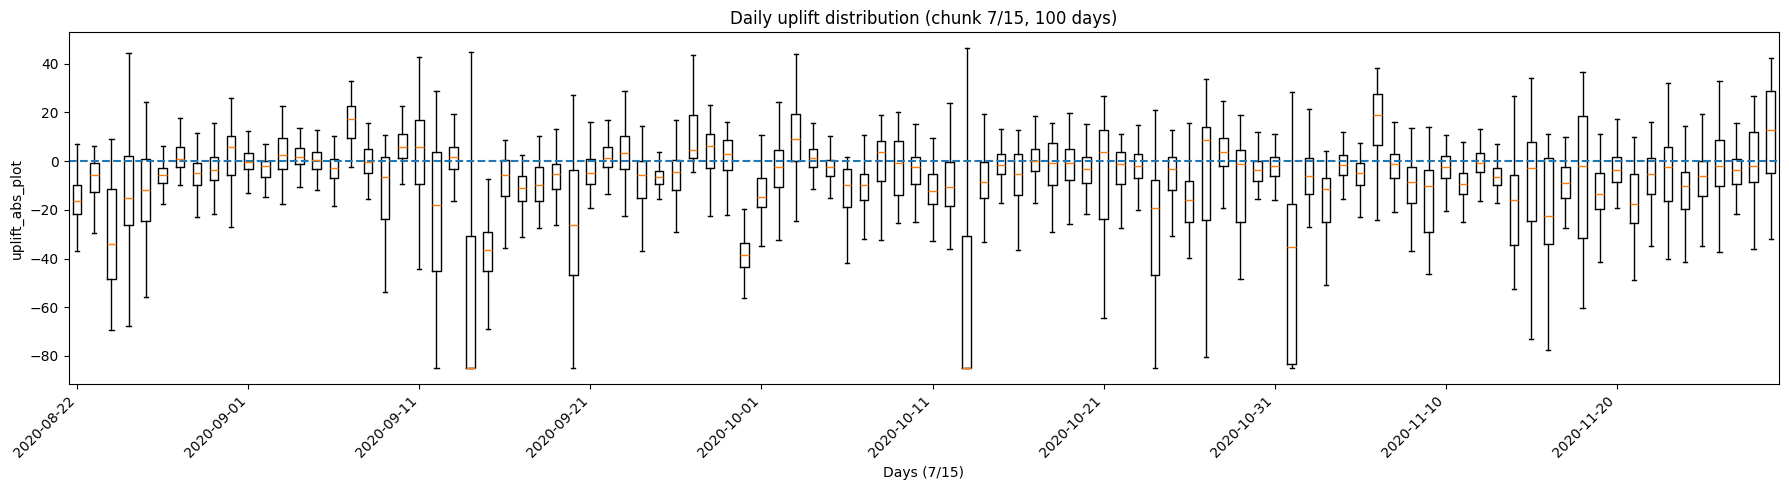

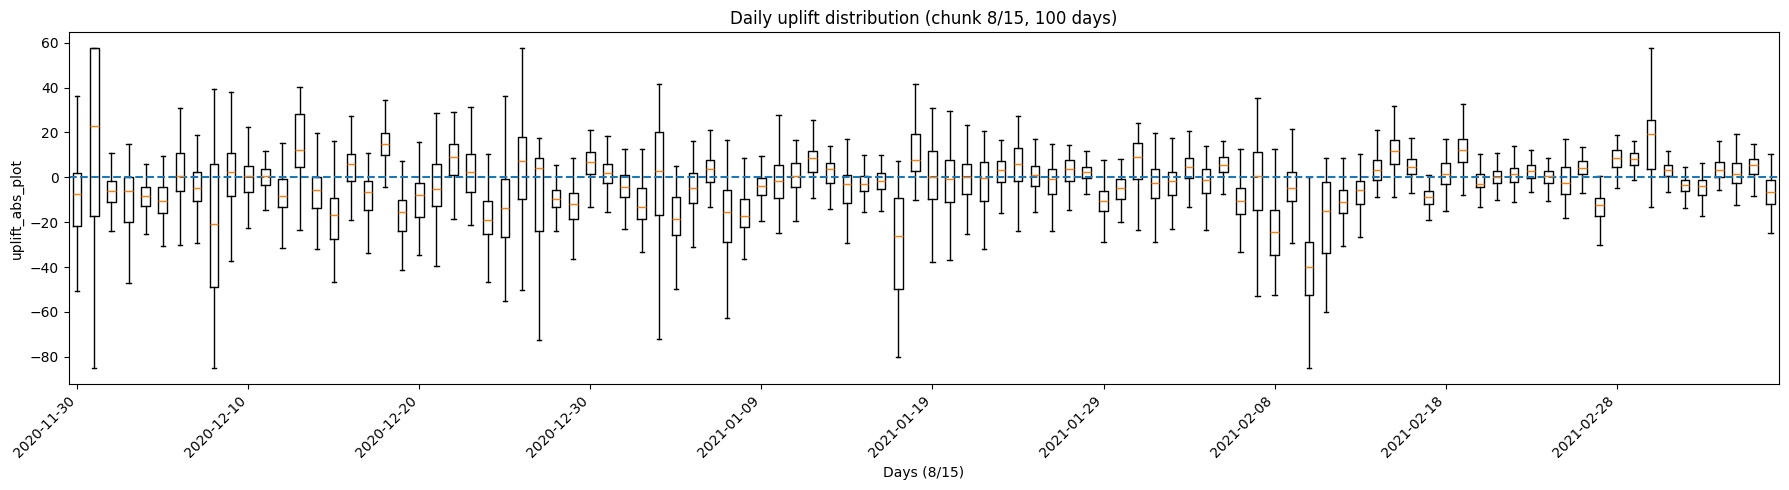

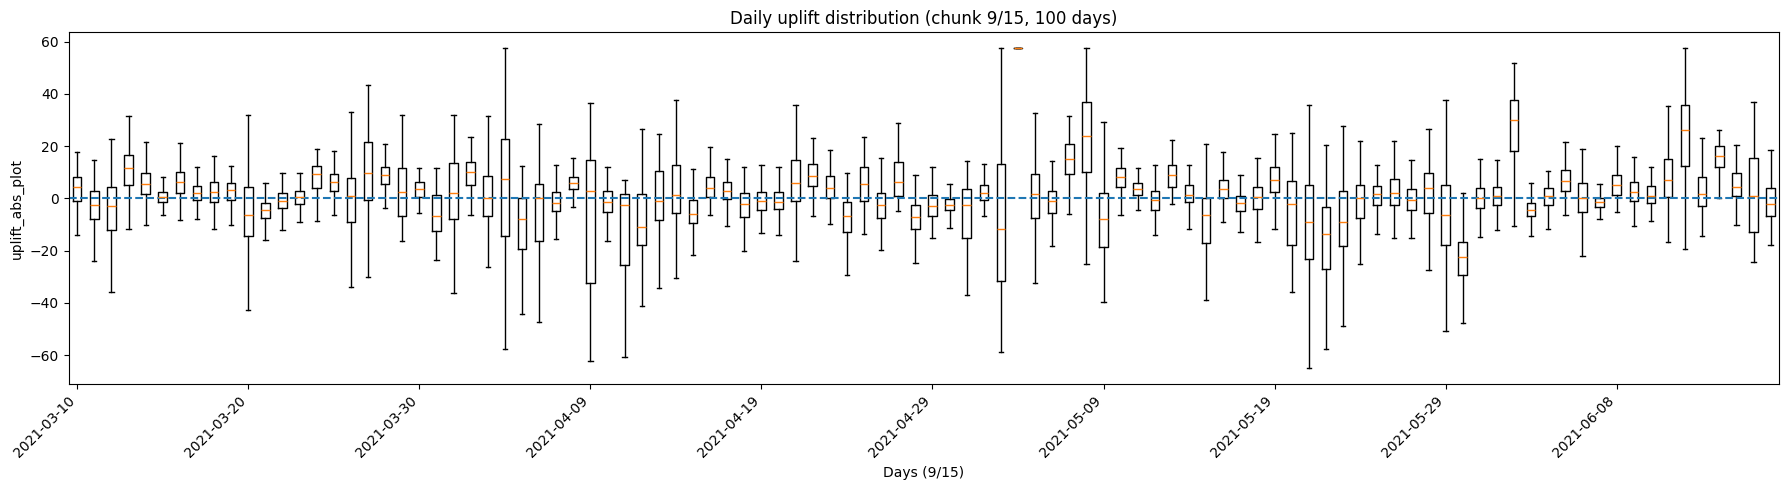

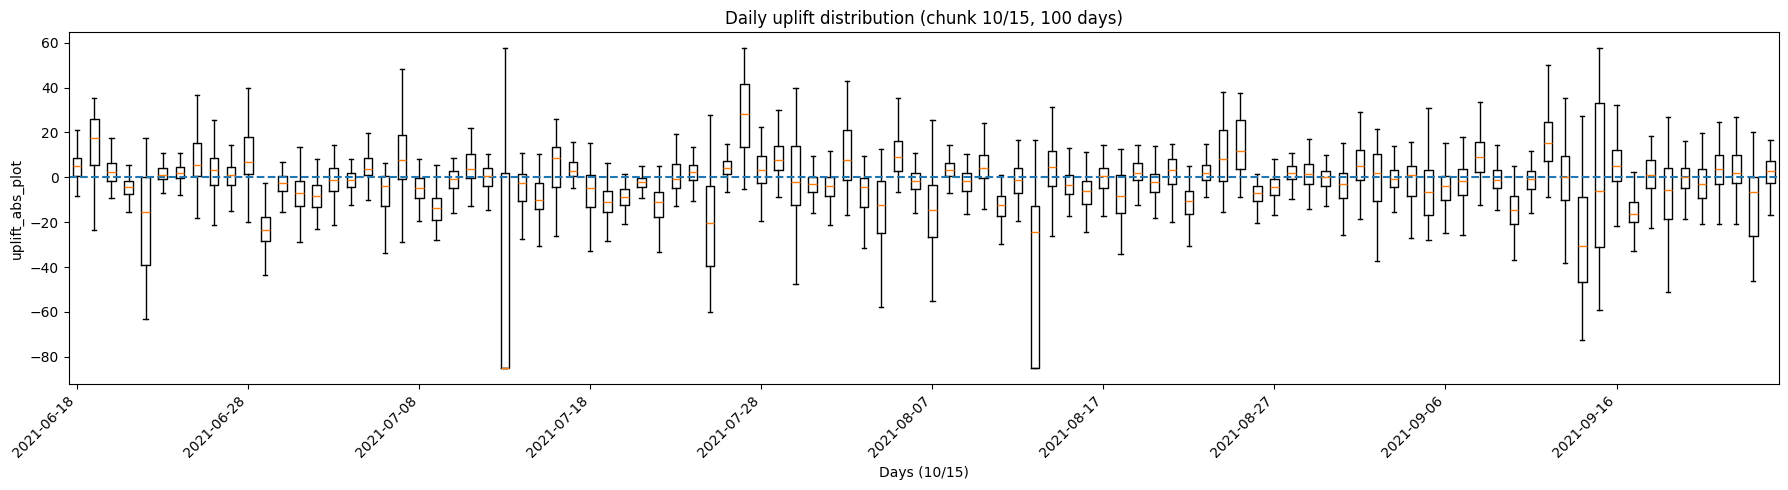

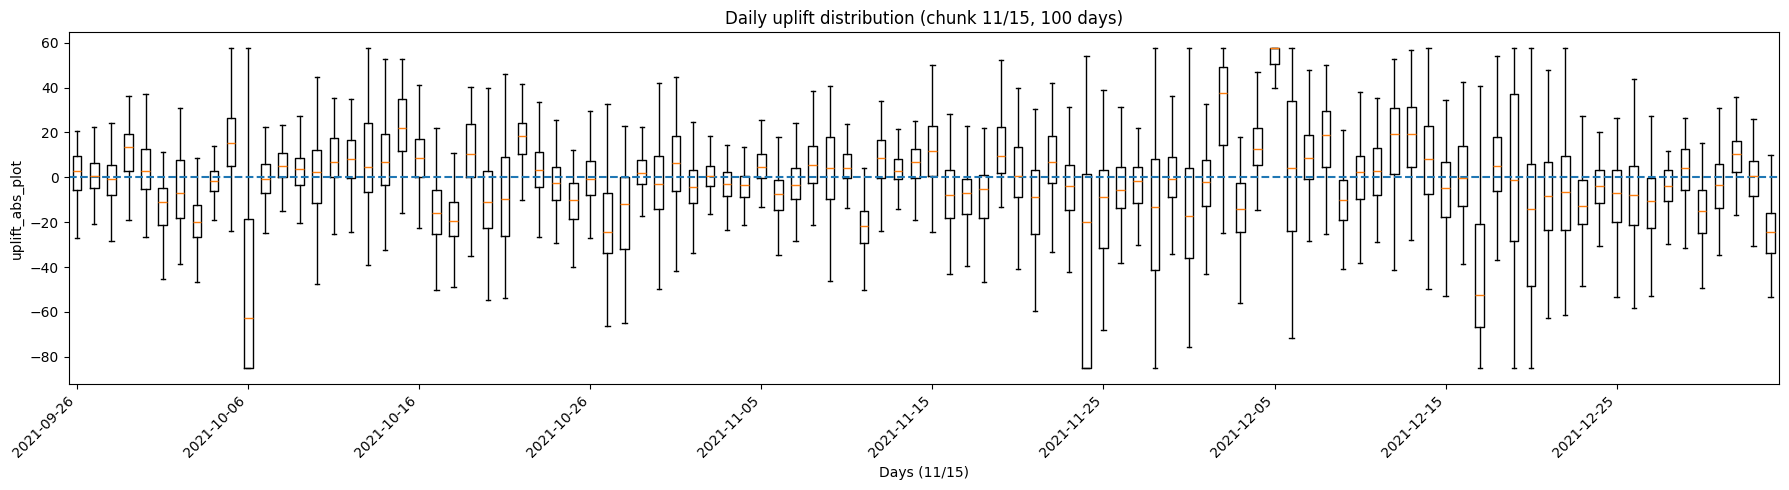

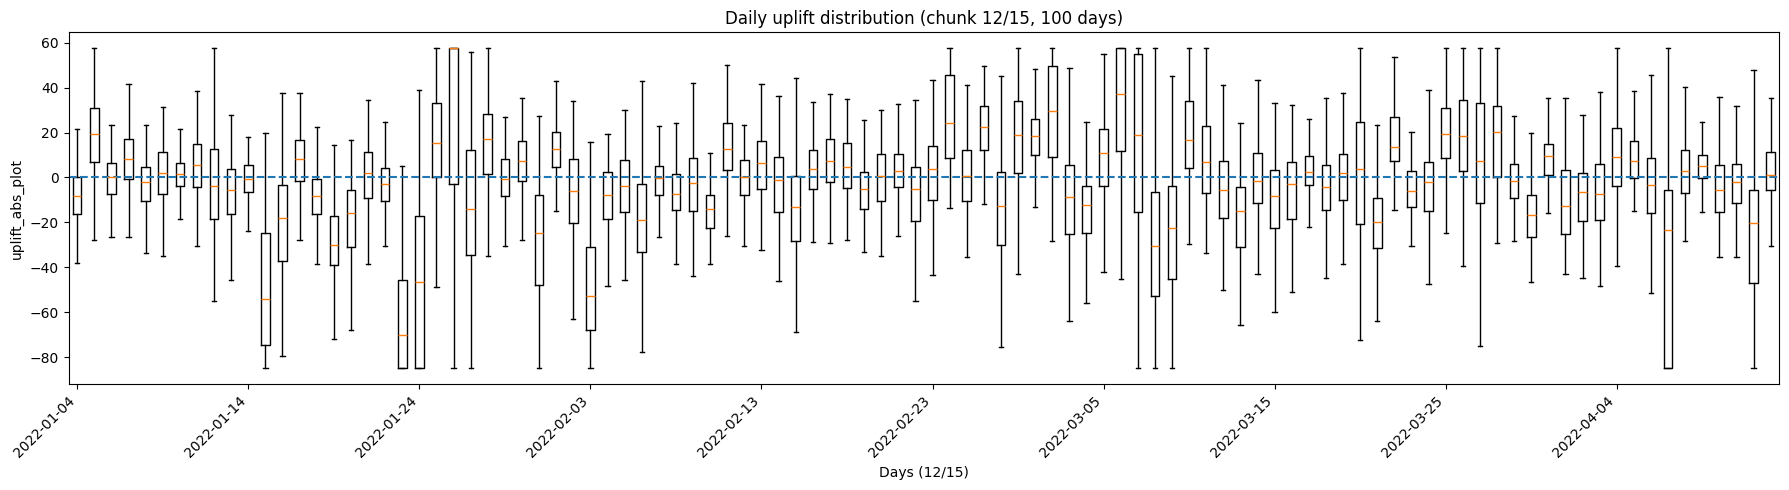

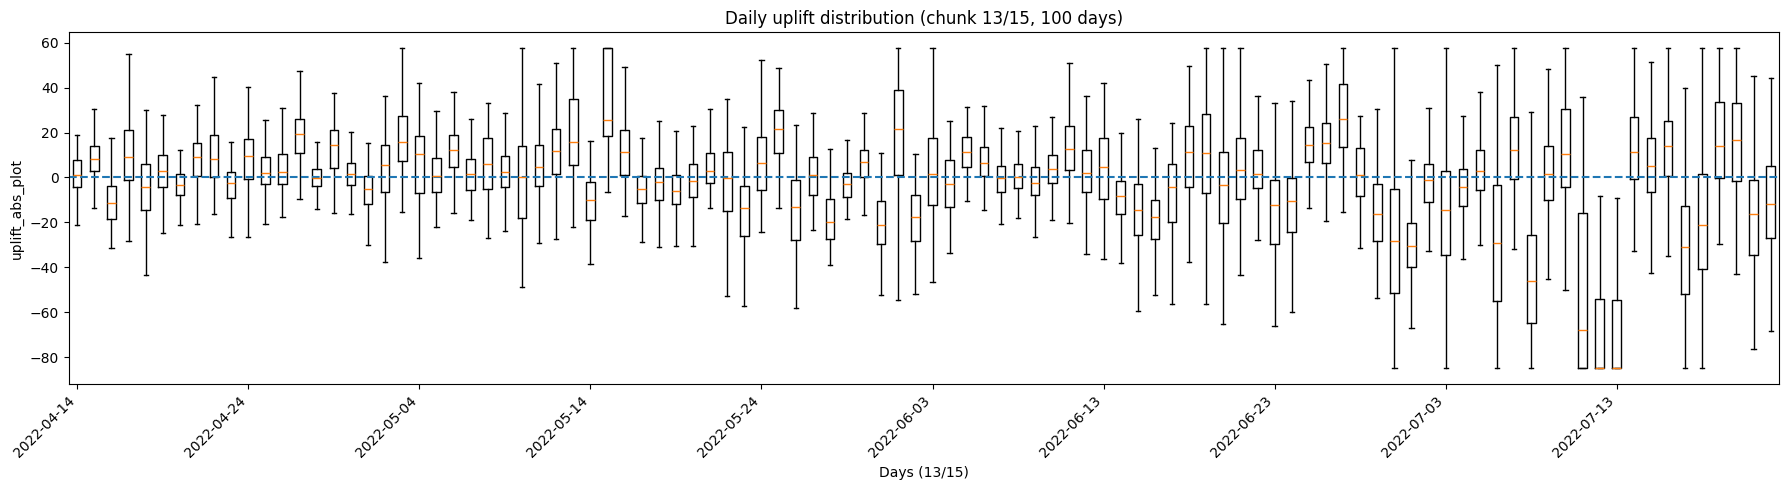

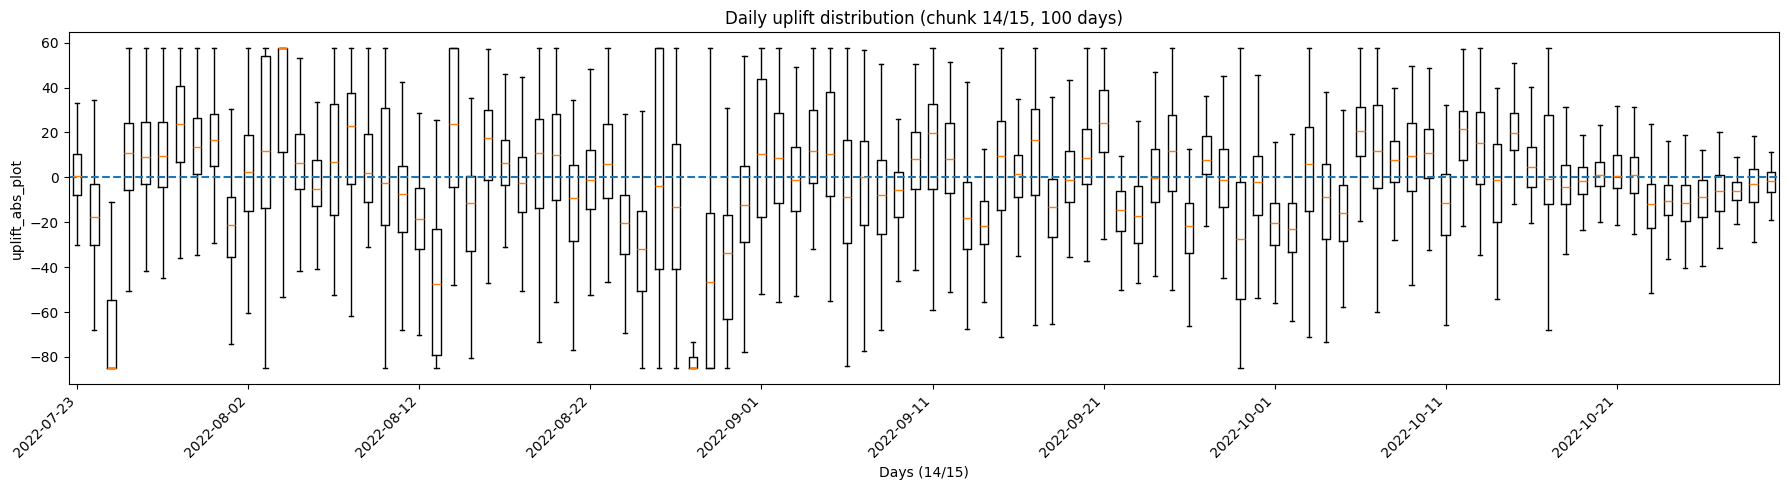

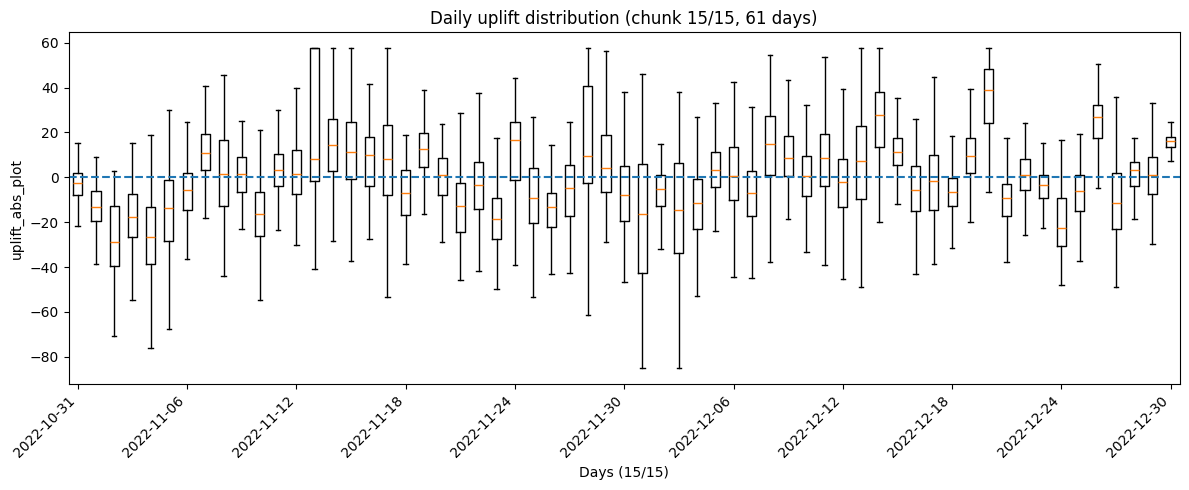

In [204]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_boxplots_by_day_chunks(
    df: pd.DataFrame,
    date_col: str = "date",
    value_col: str = "uplift_abs",
    chunk_size: int = 80,
    sort_days: str = "date",   # "date" oder "median" oder "mean"
    showfliers: bool = False,
):
    d = df[[date_col, value_col]].dropna().copy()

    # Liste aller Tage
    days = d[date_col].drop_duplicates()

    # Sortierung (optional hilfreich)
    if sort_days == "median":
        day_order = (d.groupby(date_col)[value_col].median()
                       .sort_values(ascending=True).index.tolist())
    elif sort_days == "mean":
        day_order = (d.groupby(date_col)[value_col].mean()
                       .sort_values(ascending=True).index.tolist())
    else:
        # nach Datum (sicher, wenn date echtes Date/Datetime ist)
        day_order = sorted(days.tolist())

    # Daten pro Tag einmal vorbereiten (spart Zeit)
    grouped = {day: d.loc[d[date_col] == day, value_col].values for day in day_order}

    n = len(day_order)
    n_chunks = int(np.ceil(n / chunk_size))

    for i in range(n_chunks):
        chunk_days = day_order[i*chunk_size:(i+1)*chunk_size]
        data = [grouped[day] for day in chunk_days]

        plt.figure(figsize=(max(12, len(chunk_days)*0.18), 5))
        plt.boxplot(data, showfliers=showfliers)

        # Baseline-Linie
        plt.axhline(0, linestyle="--")

        # X-Achse: nicht jeden Tag labeln (sonst zu voll)
        tick_step = max(1, len(chunk_days)//10)
        ticks = np.arange(1, len(chunk_days)+1, tick_step)
        labels = [str(chunk_days[t-1]) for t in ticks]

        plt.xticks(ticks, labels, rotation=45, ha="right")
        plt.xlabel(f"Days ({i+1}/{n_chunks})")
        plt.ylabel(value_col)
        plt.title(f"Daily uplift distribution (chunk {i+1}/{n_chunks}, {len(chunk_days)} days)")
        plt.tight_layout()
        plt.show()

q01, q99 = df["uplift_abs"].quantile([0.01, 0.99])
df["uplift_abs_plot"] = df["uplift_abs"].clip(q01, q99)
# Aufruf
plot_boxplots_by_day_chunks(
    df,
    date_col="date",
    value_col="uplift_abs_plot",
    chunk_size=100,
    sort_days="date",
    showfliers=False
)


/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_68889/1619541916.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


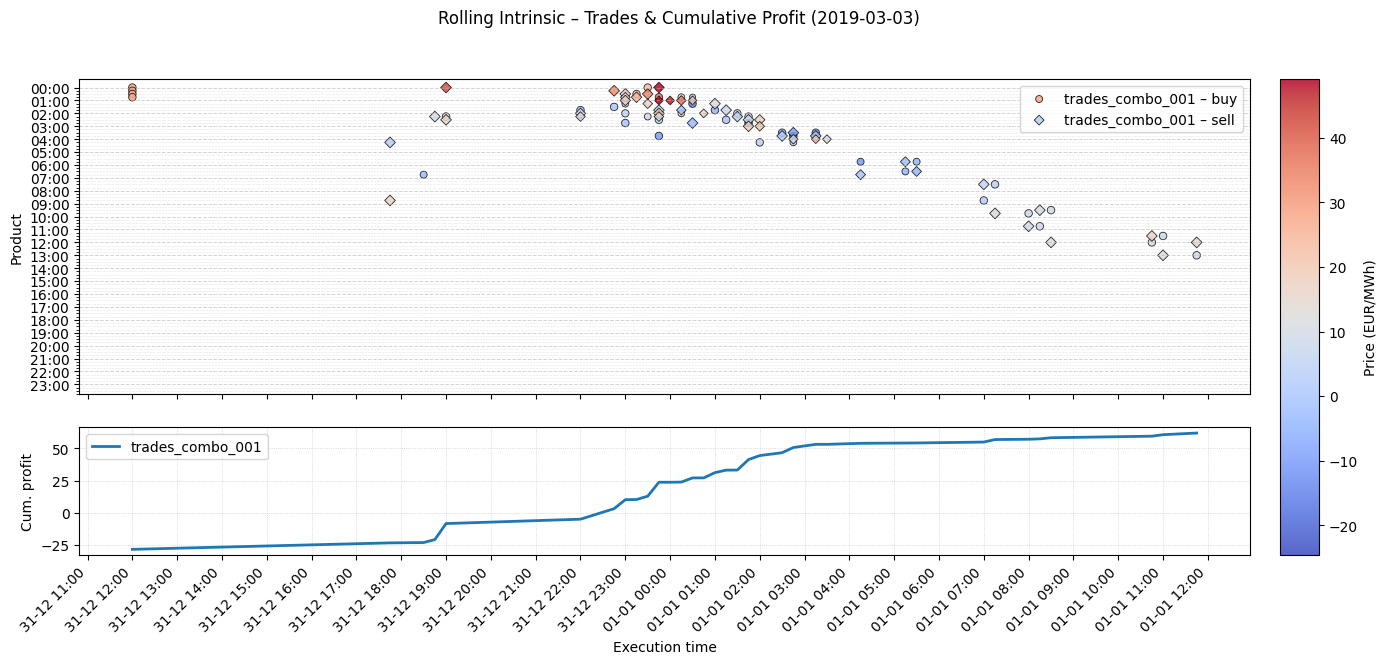

In [7]:
from __future__ import annotations

from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec


# ---------------------------------------------------------------------
# Helper
# ---------------------------------------------------------------------
def _prep_trades(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["execution_time"] = pd.to_datetime(df["execution_time"])
    df["product"] = pd.to_datetime(df["product"])

    # Product → 15-min slots (0..95)
    df["prod_min"] = df["product"].dt.hour * 60 + df["product"].dt.minute
    df["prod_slot_15m"] = (df["prod_min"] // 15).astype(int)

    df["side"] = df["side"].str.lower().str.strip()
    df = df[df["side"].isin(["buy", "sell"])]

    df["quantity"] = df["quantity"].astype(float)
    df["price"] = df["price"].astype(float)
    df["profit"] = df["profit"].astype(float)

    # numerical noise cleanup
    df.loc[df["quantity"].abs() < 1e-10, "quantity"] = 0.0

    return df


# ---------------------------------------------------------------------
# Main plotting function
# ---------------------------------------------------------------------
def plot_ri_trades_with_cum_profit(
    csv_paths: Sequence[str | Path],
    title: Optional[str] = None,
    size_by_quantity: bool = True,
    quantity_size_scale: float = 10.0,
    alpha: float = 0.85,
):
    csv_paths = [Path(p) for p in csv_paths]
    if not csv_paths:
        raise ValueError("csv_paths is empty")

    # --- Load data ---
    dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)
        df = _prep_trades(df)
        df["run"] = p.stem
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    # shared color scale
    vmin, vmax = df_all["price"].min(), df_all["price"].max()

    # --- Figure layout (scatter | profit + external colorbar) ---
    fig = plt.figure(figsize=(16, 7))
    gs = GridSpec(
        2, 2,
        width_ratios=[30, 1],
        height_ratios=[3.2, 1.3],
        wspace=0.05,
        hspace=0.15,
    )

    ax_scatter = fig.add_subplot(gs[0, 0])
    ax_profit = fig.add_subplot(gs[1, 0], sharex=ax_scatter)
    cax = fig.add_subplot(gs[:, 1])

    marker_map = {"buy": "o", "sell": "D"}

    def _sizes(q: np.ndarray) -> np.ndarray:
        if not size_by_quantity:
            return np.full_like(q, 60.0)
        qabs = np.abs(q)
        return 20.0 + quantity_size_scale * np.sqrt(qabs / (qabs.max() + 1e-12))

    # -----------------------------------------------------------------
    # Scatter + Cum Profit (overlay runs if multiple CSVs given)
    # -----------------------------------------------------------------
    mappable = None
    for run in sorted(df_all["run"].unique()):
        df_run = df_all[df_all["run"] == run]

        # --- Scatter ---
        for side in ["buy", "sell"]:
            d = df_run[df_run["side"] == side]
            if d.empty:
                continue

            sc = ax_scatter.scatter(
                d["execution_time"],
                d["prod_slot_15m"],
                c=d["price"],
                cmap="coolwarm",
                vmin=vmin,
                vmax=vmax,
                s=_sizes(d["quantity"].to_numpy()),
                marker=marker_map[side],
                alpha=alpha,
                edgecolors="black",
                linewidths=0.6,
                label=f"{run} – {side}",
            )
            mappable = sc

        # --- Cumulated profit ---
        prof = (
            df_run.groupby("execution_time", as_index=False)["profit"]
            .sum()
            .sort_values("execution_time")
        )
        prof["cum_profit"] = prof["profit"].cumsum()

        ax_profit.plot(
            prof["execution_time"],
            prof["cum_profit"],
            linewidth=2.0,
            label=run,
        )

    # -----------------------------------------------------------------
    # Formatting: Scatter
    # -----------------------------------------------------------------
    ax_scatter.set_ylabel("Product")

    hour_slots = np.arange(0, 96, 4)
    ax_scatter.set_yticks(hour_slots)
    ax_scatter.set_yticklabels([f"{h//4:02d}:00" for h in hour_slots])

    ax_scatter.set_yticks(np.arange(0, 96), minor=True)
    ax_scatter.grid(which="minor", axis="y", linestyle="--", linewidth=0.4, alpha=0.35)
    ax_scatter.grid(which="major", axis="y", linestyle="--", linewidth=0.7, alpha=0.55)

    ax_scatter.invert_yaxis()
    ax_scatter.legend(loc="upper right")

    # -----------------------------------------------------------------
    # Formatting: Profit
    # -----------------------------------------------------------------
    ax_profit.set_ylabel("Cum. profit")
    ax_profit.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
    ax_profit.legend(loc="upper left")

    # -----------------------------------------------------------------
    # Shared X axis (HOURLY ticks like first version)
    # -----------------------------------------------------------------
    ax_profit.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax_profit.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))
    ax_profit.set_xlabel("Execution time")

    fig.autofmt_xdate(rotation=45, ha="right")

    # -----------------------------------------------------------------
    # Colorbar (external, clean)
    # -----------------------------------------------------------------
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label("Price (EUR/MWh)")

    if title:
        fig.suptitle(title, y=0.98)

    fig.tight_layout()
    return fig, (ax_scatter, ax_profit)


# ---------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------
if __name__ == "__main__":
    plot_ri_trades_with_cum_profit(
        csv_paths=[
            "results/trades/2019-01-01/trades_combo_001.csv",
            #"results/trades/2019-03-03/trades_combo_279.csv",
        ],
        title="Rolling Intrinsic – Trades & Cumulative Profit (2019-03-03)",
    )
    plt.show()


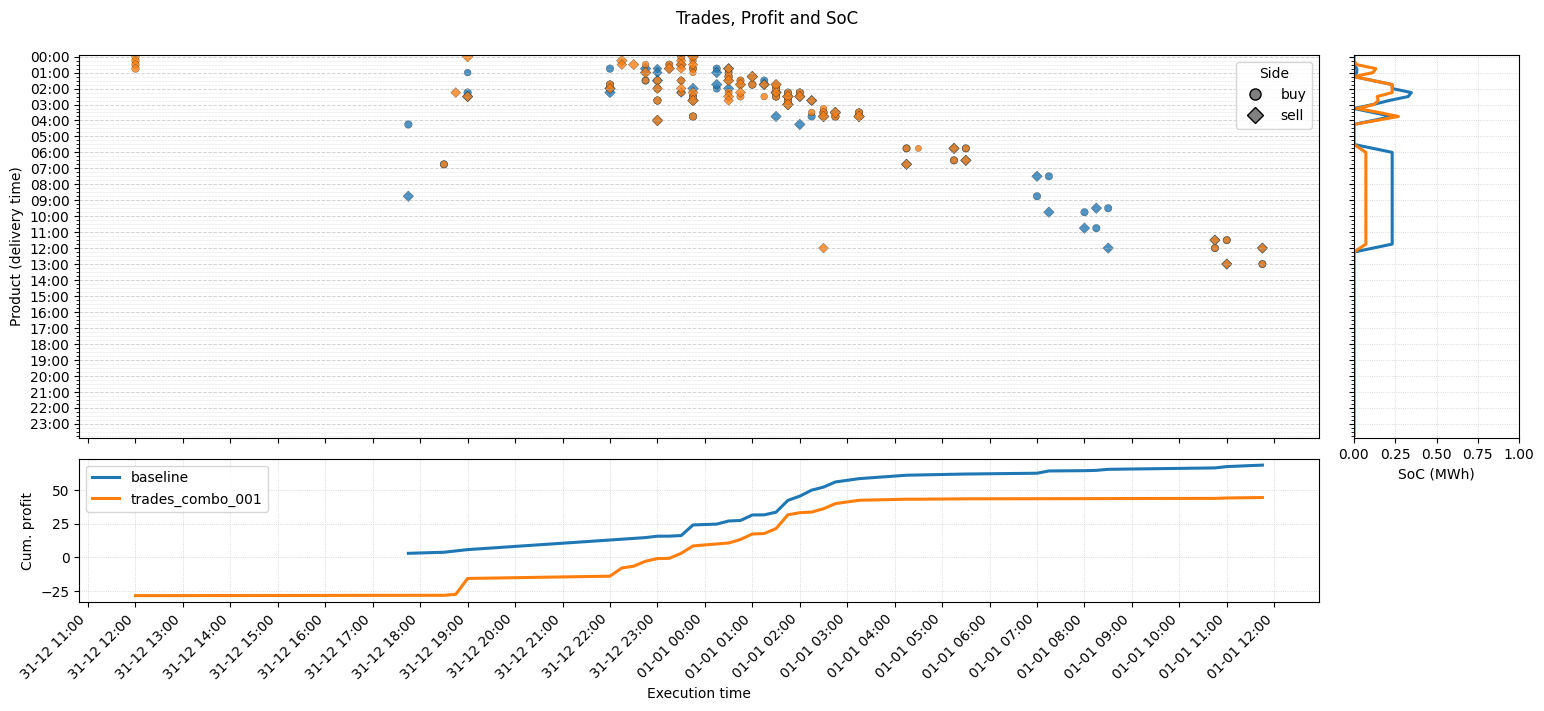

In [21]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D


# ============================================================
# Helpers
# ============================================================
def _prep_trades(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["execution_time"] = pd.to_datetime(df["execution_time"])
    df["product"] = pd.to_datetime(df["product"])

    # product → 15-min slot index (0..95)
    df["prod_min"] = df["product"].dt.hour * 60 + df["product"].dt.minute
    df["prod_slot_15m"] = (df["prod_min"] // 15).astype(int)

    df["side"] = df["side"].str.lower().str.strip()
    df = df[df["side"].isin(["buy", "sell"])]

    df["quantity"] = df["quantity"].astype(float)
    df["profit"] = df["profit"].astype(float)

    df.loc[df["quantity"].abs() < 1e-10, "quantity"] = 0.0
    return df


def _soc_by_product_slots(
    df_run: pd.DataFrame,
    E_max_mwh: float,
    soc0_mwh: float,
    dt_hours: float,
    eta_ch: float,
    eta_dis: float,
) -> Tuple[np.ndarray, np.ndarray]:
    sign = df_run["side"].map({"buy": +1.0, "sell": -1.0}).astype(float)
    p_signed = sign * df_run["quantity"].astype(float)

    sched = (
        pd.DataFrame({"slot": df_run["prod_slot_15m"], "p_mw_signed": p_signed})
        .groupby("slot", as_index=False)["p_mw_signed"]
        .sum()
        .sort_values("slot")
    )

    # ensure full 0..95 grid
    full = pd.DataFrame({"slot": np.arange(0, 96)})
    sched = full.merge(sched, on="slot", how="left").fillna({"p_mw_signed": 0.0})

    e_slot = sched["p_mw_signed"].to_numpy() * dt_hours
    e_batt = np.where(e_slot >= 0, e_slot * eta_ch, e_slot / eta_dis)

    soc = np.empty(len(e_batt) + 1)
    soc[0] = soc0_mwh
    for i in range(len(e_batt)):
        soc[i + 1] = np.clip(soc[i] + e_batt[i], 0.0, E_max_mwh)

    # map SoC to slot centers (0..95) → perfect alignment
    soc_center = 0.5 * (soc[:-1] + soc[1:])
    y_slots = np.arange(0, 96)

    return y_slots, soc_center


# ============================================================
# Main plot
# ============================================================
def plot_ri_trades_profit_soc(
    csv_paths: Sequence[str | Path],
    title: Optional[str] = None,
    run_labels: Optional[Dict[str, str]] = None,
    # scatter
    size_by_quantity: bool = True,
    quantity_size_scale: float = 10.0,
    alpha: float = 0.9,
    # SoC params
    E_max_mwh: float = 1.0,
    soc0_mwh: float = 0.5,
    dt_hours: float = 0.25,
    eta_ch: float = 1.0,
    eta_dis: float = 1.0,
):
    csv_paths = [Path(p) for p in csv_paths]
    if not csv_paths:
        raise ValueError("csv_paths is empty")

    # load data
    dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)
        df = _prep_trades(df)
        df["run"] = p.stem
        dfs.append(df)
    df_all = pd.concat(dfs, ignore_index=True)

    runs = sorted(df_all["run"].unique())
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = {run: colors[i % len(colors)] for i, run in enumerate(runs)}
    marker_map = {"buy": "o", "sell": "D"}

    def _sizes(q):
        if not size_by_quantity:
            return np.full_like(q, 60.0)
        qabs = np.abs(q)
        return 20 + quantity_size_scale * np.sqrt(qabs / (qabs.max() + 1e-12))

    # ========================================================
    # Layout
    # ========================================================
    fig = plt.figure(figsize=(16, 7.5))
    gs = GridSpec(
        2, 2,
        height_ratios=[3.2, 1.2],
        width_ratios=[4.5, 0.6],
        hspace=0.08,
        wspace=0.05,
    )

    ax_trades = fig.add_subplot(gs[0, 0])
    ax_profit = fig.add_subplot(gs[1, 0], sharex=ax_trades)
    ax_soc = fig.add_subplot(gs[0, 1], sharey=ax_trades)
    ax_dummy = fig.add_subplot(gs[1, 1])  # keeps SoC x-labels alive
    ax_dummy.axis("off")

    # ========================================================
    # Plot per run
    # ========================================================
    
    for run in runs:
        df_run = df_all[df_all["run"] == run]
        c = color_map[run]
        label = run_labels.get(run, run) if run_labels else run

        # trades
        for side in ["buy", "sell"]:
            d = df_run[df_run["side"] == side]
            ax_trades.scatter(
                d["execution_time"],
                d["prod_slot_15m"],
                s=_sizes(d["quantity"].to_numpy()),
                color=c,
                marker=marker_map[side],
                alpha=0.8,
                edgecolors="black",
                linewidths=0.2,
            )

        # profit
        prof = (
            df_run.groupby("execution_time", as_index=False)["profit"]
            .sum()
            .sort_values("execution_time")
        )
        prof["cum_profit"] = prof["profit"].cumsum()
        ax_profit.plot(prof["execution_time"], prof["cum_profit"], color=c, linewidth=2.2, label=label)

        # SoC
        y_slots, soc = _soc_by_product_slots(
            df_run,
            E_max_mwh, soc0_mwh, dt_hours, eta_ch, eta_dis
        )
        ax_soc.plot(soc, y_slots, color=c, linewidth=2.2, label=label)

    # ========================================================
    # Formatting
    # ========================================================

    # Y axis = product time (forward!)
    ax_trades.set_ylim(95.5, -0.5)
    hour_slots = np.arange(0, 96, 4)
    ax_trades.set_yticks(hour_slots)
    ax_trades.set_yticklabels([f"{h//4:02d}:00" for h in hour_slots])
    ax_trades.set_yticks(np.arange(0, 96), minor=True)
    ax_trades.grid(which="minor", axis="y", linestyle="--", linewidth=0.4, alpha=0.35)
    ax_trades.grid(which="major", axis="y", linestyle="--", linewidth=0.7, alpha=0.55)
    ax_trades.set_ylabel("Product (delivery time)")

    # hide upper x labels
    plt.setp(ax_trades.get_xticklabels(), visible=False)

    # profit axis
    ax_profit.set_ylabel("Cum. profit")
    ax_profit.set_xlabel("Execution time")
    ax_profit.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
    ax_profit.legend(loc="upper left")

    ax_profit.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax_profit.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))

    # SoC axis
    ax_soc.set_xlabel("SoC (MWh)")
    ax_soc.set_xlim(0, E_max_mwh)
    ax_soc.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax_soc.tick_params(axis="x", labelbottom=True)
    ax_soc.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
    plt.setp(ax_soc.get_yticklabels(), visible=False)

    # marker legend (buy/sell)
    side_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=8, label="buy"),
        Line2D([0], [0], marker="D", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=8, label="sell"),
    ]
    ax_trades.legend(handles=side_handles, loc="upper right", title="Side")

    if title:
        fig.suptitle(title, y=0.99)

    fig.subplots_adjust(left=0.07, right=0.97, top=0.93, bottom=0.1)
    fig.autofmt_xdate(rotation=45, ha="right")
    
    # ---- FORCE SoC x-axis labels ----
    ax_soc.set_xlabel("SoC (MWh)")
    ax_soc.set_xlim(0, E_max_mwh)

    ax_soc.tick_params(
        axis="x",
        which="both",
        labelbottom=True
    )

    return fig, (ax_trades, ax_profit, ax_soc)


# ============================================================
# Example
# ============================================================
if __name__ == "__main__":
    plot_ri_trades_profit_soc(
        csv_paths=[
            "results_open_positions_V1/trades/2019-01-01/trades_combo_000.csv",
            #"results_open_positions_V1/trades/2019-01-01/trades_combo_001.csv",
            "results_open_positions_V2/trades/2019-01-01/trades_combo_001.csv",
        ],
        run_labels={"trades_combo_000": "baseline"},
        title="Trades, Profit and SoC",
        E_max_mwh=1.0,
        soc0_mwh=0.0,
        eta_ch=0.86**0.5,
        eta_dis=0.86/(1/0.86**0.5),
    )
    plt.show()


#### Load drl observation space features

In [207]:
drl_obs_data = pd.read_csv("../data/simplified_data_jan_with_exaa_and_id_full/df_spot_train_2019-01-01_2024-12-31_with_features_utc.csv")
drl_obs_data["time"] = pd.to_datetime(drl_obs_data["time"], utc=True)
drl_obs_data.set_index("time", inplace=True)
drl_obs_data = drl_obs_data.resample('D').mean()
drl_obs_data.reset_index(inplace=True)
drl_obs_data["date"] = drl_obs_data["time"].dt.date
drl_obs_data

df["day"] = pd.to_datetime(df["day"].astype(str).str.slice(0, 10), errors="coerce")
df["day_utc"] = df["day"].dt.tz_localize("UTC")
df["date"] = df["day_utc"].dt.date
df

df_merged = df.merge(
    drl_obs_data,
    on="date",
    how="left"
)

In [208]:
df1= df_merged.copy()

In [209]:
columns_to_keep = [ 'date','buy_hour', 'sell_hour',
      'uplift_abs', 'uplift_pct',
       'load_forecast_d_minus_1_1000_total_de_lu_mw',
       'pv_forecast_d_minus_1_1000_de_lu_mw',
       'wind_offshore_forecast_d_minus_1_1000_de_lu_mw',
       'wind_onshore_forecast_d_minus_1_1000_de_lu_mw', 'date_month',
       'day_of_week', 'wind_forecast_daily_mean', 'wind_forecast_daily_std',
       'spread_id_full_da_h_mean', 'spread_id_full_da_h_std',
       'spread_id_full_da_h_min', 'spread_id_full_da_h_max',
       'spread_id_full_da_qh_mean', 'spread_id_full_da_qh_std',
       'spread_id_full_da_qh_min', 'spread_id_full_da_qh_max',
       'exaa_pf_daily_mean', 'exaa_pf_daily_std', 'exaa_pf_daily_min',
       'exaa_pf_daily_max', 'exaa_pf_daily_spread', 'exaa_pf_daily_diff_sum',
       'exaa_pf_daily_diff_max']

df= df_merged[columns_to_keep]



df["buy_hour"] = df["buy_hour"].fillna(0)
df["sell_hour"] = df["sell_hour"].fillna(0)

/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_38790/1866301903.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["buy_hour"] = df["buy_hour"].fillna(0)
/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_38790/1866301903.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sell_hour"] = df["sell_hour"].fillna(0)


In [210]:
"""

import numpy as np
import pandas as pd

def add_action_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Sicherstellen: int
    df["buy_hour"]  = df["buy_hour"].fillna(0).astype(int)
    df["sell_hour"] = df["sell_hour"].fillna(0).astype(int)

    df["has_buy"]  = (df["buy_hour"]  > 0).astype(int)
    df["has_sell"] = (df["sell_hour"] > 0).astype(int)
    df["is_roundtrip"] = ((df["has_buy"] == 1) & (df["has_sell"] == 1)).astype(int)

    # Haltedauer nur wenn roundtrip; sonst 0
    df["hold_duration"] = (df["sell_hour"] - df["buy_hour"]).astype(int)
    df.loc[df["is_roundtrip"] == 0, "hold_duration"] = 0

    # Grobe Zeit-Bins (interpretierbar)
    df["buy_is_early"]   = df["buy_hour"].between(1, 6).astype(int)
    df["buy_is_midday"]  = df["buy_hour"].between(7, 14).astype(int)
    df["buy_is_late"]    = df["buy_hour"].between(15, 23).astype(int)

    df["sell_is_early"]  = df["sell_hour"].between(1, 6).astype(int)
    df["sell_is_midday"] = df["sell_hour"].between(7, 14).astype(int)
    df["sell_is_evening"]= df["sell_hour"].between(17, 23).astype(int)

    # "Flexibility locks" Proxies (DA schränkt IDC ein)
    df["locks_energy_early"] = (df["buy_hour"] <= 6).astype(int) * df["has_buy"]
    df["locks_energy_long"]  = (df["hold_duration"] >= 6).astype(int) * df["is_roundtrip"]
    df["locks_peak_hours"]   = df["sell_hour"].between(17, 21).astype(int) * df["has_sell"]

    # Optional: Kategorie-Label für Aktion (gut für CatBoost; für LGBM eher optional)
    #df["action_id"] = df["buy_hour"].astype(str) + "_" + df["sell_hour"].astype(str)

    return df

df = add_action_features(df)

"""


'\n\nimport numpy as np\nimport pandas as pd\n\ndef add_action_features(df: pd.DataFrame) -> pd.DataFrame:\n    df = df.copy()\n\n    # Sicherstellen: int\n    df["buy_hour"]  = df["buy_hour"].fillna(0).astype(int)\n    df["sell_hour"] = df["sell_hour"].fillna(0).astype(int)\n\n    df["has_buy"]  = (df["buy_hour"]  > 0).astype(int)\n    df["has_sell"] = (df["sell_hour"] > 0).astype(int)\n    df["is_roundtrip"] = ((df["has_buy"] == 1) & (df["has_sell"] == 1)).astype(int)\n\n    # Haltedauer nur wenn roundtrip; sonst 0\n    df["hold_duration"] = (df["sell_hour"] - df["buy_hour"]).astype(int)\n    df.loc[df["is_roundtrip"] == 0, "hold_duration"] = 0\n\n    # Grobe Zeit-Bins (interpretierbar)\n    df["buy_is_early"]   = df["buy_hour"].between(1, 6).astype(int)\n    df["buy_is_midday"]  = df["buy_hour"].between(7, 14).astype(int)\n    df["buy_is_late"]    = df["buy_hour"].between(15, 23).astype(int)\n\n    df["sell_is_early"]  = df["sell_hour"].between(1, 6).astype(int)\n    df["sell_is_mid

In [211]:
df["uplift_pos"] = (df["uplift_abs"] > 0.0).astype(int)
#df["uplift_pos_5pct"] = (df["uplift_pct"] > 0.2).astype(int)


/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_38790/467688653.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uplift_pos"] = (df["uplift_abs"] > 0.0).astype(int)


In [212]:
from sklearn.model_selection import GroupShuffleSplit

y = df["uplift_pos"].values

exclude = {
    "uplift_abs","uplift_pct","uplift_pos","uplift_pos_5pct",
    "day","time","datetime","date"
}
candidate_cols = [c for c in df.columns if c not in exclude]

groups = df["date"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(df, y, groups=groups))

X_train = df.iloc[train_idx][candidate_cols]
y_train = df.iloc[train_idx]["uplift_pos"]
X_test  = df.iloc[test_idx][candidate_cols]
y_test  = df.iloc[test_idx]["uplift_pos"]



In [213]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

model = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

p_test = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, p_test))
print("PR-AUC :", average_precision_score(y_test, p_test))


[LightGBM] [Info] Number of positive: 36009, number of negative: 51591
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001791 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5441
[LightGBM] [Info] Number of data points in the train set: 87600, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.411062 -> initscore=-0.359578
[LightGBM] [Info] Start training from score -0.359578
ROC-AUC: 0.5872888502650448
PR-AUC : 0.48984725814474506


In [214]:
import numpy as np

def recall_at_topk(y_true, y_score, k_frac=0.2):
    k = int(len(y_true) * k_frac)
    idx = np.argsort(-y_score)[:k]
    return y_true.iloc[idx].sum() / max(1, y_true.sum())

print("Recall@Top20%:", recall_at_topk(y_test, pd.Series(p_test, index=y_test.index), 0.2))


Recall@Top20%: 0.24718076454534937


In [215]:
import pandas as pd

imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(30))


buy_hour                                          8071
sell_hour                                         7633
load_forecast_d_minus_1_1000_total_de_lu_mw       3139
pv_forecast_d_minus_1_1000_de_lu_mw               3024
wind_offshore_forecast_d_minus_1_1000_de_lu_mw    2495
wind_forecast_daily_std                           2294
wind_onshore_forecast_d_minus_1_1000_de_lu_mw     2225
spread_id_full_da_h_mean                          2053
spread_id_full_da_h_min                           1864
spread_id_full_da_h_std                           1749
spread_id_full_da_h_max                           1709
exaa_pf_daily_min                                 1459
exaa_pf_daily_mean                                1376
day_of_week                                       1362
exaa_pf_daily_std                                 1334
wind_forecast_daily_mean                          1241
exaa_pf_daily_diff_max                            1182
date_month                                        1120
exaa_pf_da

/Users/timflaschel/Documents/GitHub/BessBidder1/.venv/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


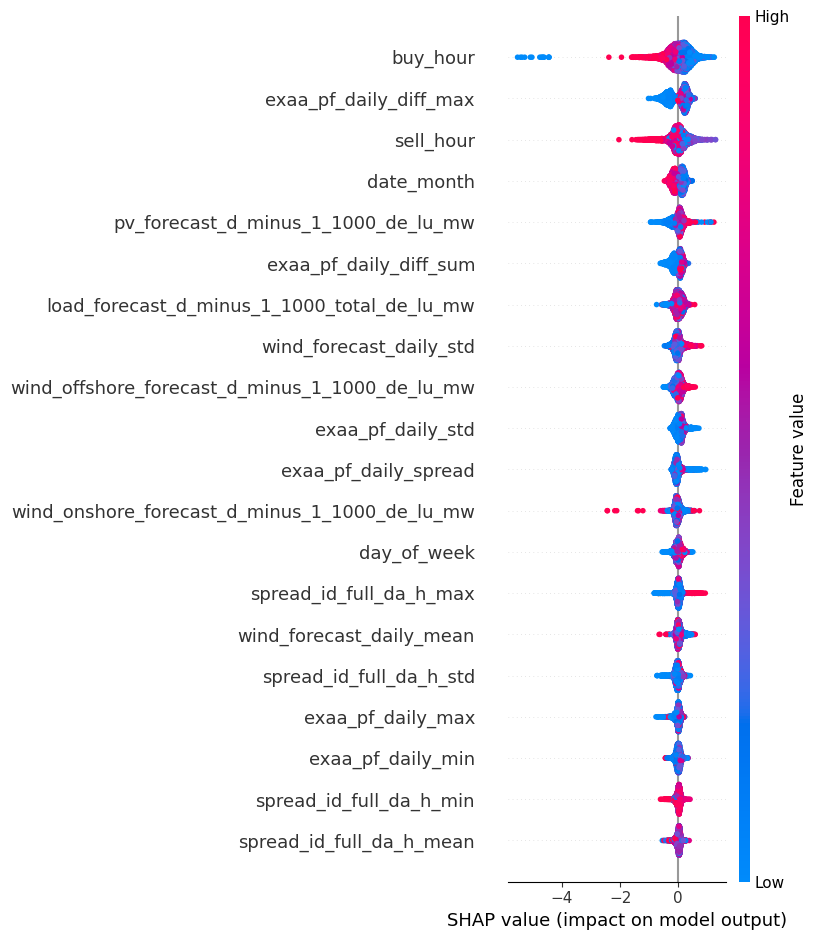

In [216]:
import shap

explainer = shap.TreeExplainer(model)
# Für Geschwindigkeit: sample
sample_idx = X_test.sample(n=min(5000, len(X_test)), random_state=42).index
X_s = X_test.loc[sample_idx]

shap_values = explainer.shap_values(X_s)
# Falls Liste:
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Global summary
shap.summary_plot(shap_values, X_s)


In [217]:
df_corr = df.drop(columns=["date"])

corr_with_uplift = (
    df_corr
    .corr(method="pearson")["uplift_abs"]
    .sort_values(ascending=False)
)

corr_with_uplift.head(30)

uplift_abs                                        1.000000
uplift_pct                                        0.651363
uplift_pos                                        0.582665
pv_forecast_d_minus_1_1000_de_lu_mw               0.035300
wind_forecast_daily_std                           0.034602
spread_id_full_da_h_std                           0.034457
spread_id_full_da_qh_std                          0.034457
spread_id_full_da_qh_max                          0.030586
spread_id_full_da_h_max                           0.030586
exaa_pf_daily_std                                 0.021751
exaa_pf_daily_spread                              0.018537
day_of_week                                       0.018141
exaa_pf_daily_mean                                0.017421
exaa_pf_daily_max                                 0.017300
exaa_pf_daily_diff_sum                            0.012743
exaa_pf_daily_min                                 0.012624
load_forecast_d_minus_1_1000_total_de_lu_mw       0.0099

In [218]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [219]:
# Target
y_col = "uplift_pct"

# Groups (pro Tag)
group_col = "date"
groups = df[group_col]

# Excludes (Targets + Zeitspalten etc.)
exclude = {
    "uplift_abs", "uplift_pct",
    "uplift_pos", "uplift_pos_5pct",
    "day", "time", "datetime", group_col
}
feature_cols = [c for c in df.columns if c not in exclude]

X = df[feature_cols]
y = df[y_col]

# Split by day
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]



In [220]:
use_lgbm = True
try:
    from lightgbm import LGBMRegressor
except Exception:
    use_lgbm = False

if use_lgbm:
    model = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=127,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        #max_depth= 3,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
else:
    from sklearn.ensemble import HistGradientBoostingRegressor
    model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=None,
        max_iter=800,
        random_state=42
    )

model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = mean_squared_error(y_test, pred)
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5455
[LightGBM] [Info] Number of data points in the train set: 350400, number of used features: 25
[LightGBM] [Info] Start training from score -0.031718
RMSE: 0.04554986731643083
MAE : 0.13887715473515633
R2  : 0.015492050963895942


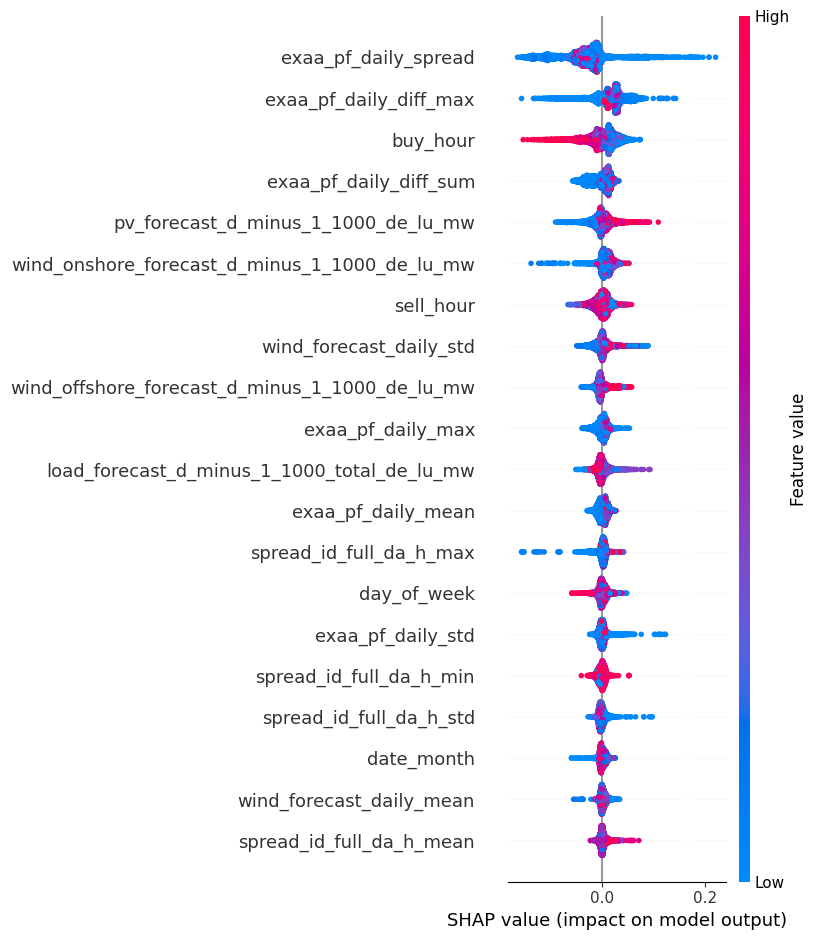

In [221]:
import shap

sample_n = 5000
X_shap = X_test.sample(n=min(sample_n, len(X_test)), random_state=42)

if use_lgbm:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
else:
    explainer = shap.Explainer(model, X_train.sample(n=2000, random_state=42))
    shap_values = explainer(X_shap)

# Summary plot (global importance + direction)
shap.summary_plot(shap_values, X_shap)


#### predict median of daily combiantions

In [222]:
df.columns
df1

,day,combo_id,kind,buy_hour,sell_hour,profit,da_exec_time,da_profit,da_buy_price,da_sell_price,...,spread_id_full_da_qh_std,spread_id_full_da_qh_min,spread_id_full_da_qh_max,exaa_pf_daily_mean,exaa_pf_daily_std,exaa_pf_daily_min,exaa_pf_daily_max,exaa_pf_daily_spread,exaa_pf_daily_diff_sum,exaa_pf_daily_diff_max
0,2018-12-31,0,no_da,0.0,0.0,68.233139,2018-12-31 13:00:00,0.00,NaN,NaN,...,NaN,NaN,NaN,-3.800833,11.401141,-20.000000,20.000000,40.000000,109.190000,16.760000
1,2018-12-31,1,buy_only,1.0,0.0,61.759133,2018-12-31 13:00:00,-28.32,28.32,NaN,...,NaN,NaN,NaN,-3.800833,11.401141,-20.000000,20.000000,40.000000,109.190000,16.760000
2,2018-12-31,2,buy_only,2.0,0.0,60.593526,2018-12-31 13:00:00,-10.07,10.07,NaN,...,NaN,NaN,NaN,-3.800833,11.401141,-20.000000,20.000000,40.000000,109.190000,16.760000
3,2018-12-31,3,buy_only,3.0,0.0,80.214991,2018-12-31 13:00:00,4.08,-4.08,NaN,...,NaN,NaN,NaN,-3.800833,11.401141,-20.000000,20.000000,40.000000,109.190000,16.760000
4,2018-12-31,4,buy_only,4.0,0.0,69.708946,2018-12-31 13:00:00,9.91,-9.91,NaN,...,NaN,NaN,NaN,-3.800833,11.401141,-20.000000,20.000000,40.000000,109.190000,16.760000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438295,2022-12-30,295,buy_sell,21.0,23.0,72.371760,NaN,NaN,NaN,NaN,...,8.186043,-24.123996,3.054402,20.718038,15.629810,-0.105417,57.515417,57.620833,127.232083,24.234583
438296,2022-12-30,296,buy_sell,21.0,24.0,70.610094,NaN,NaN,NaN,NaN,...,8.186043,-24.123996,3.054402,20.718038,15.629810,-0.105417,57.515417,57.620833,127.232083,24.234583
438297,2022-12-30,297,buy_sell,22.0,23.0,74.938620,NaN,NaN,NaN,NaN,...,8.186043,-24.123996,3.054402,20.718038,15.629810,-0.105417,57.515417,57.620833,127.232083,24.234583
438298,2022-12-30,298,buy_sell,22.0,24.0,73.176954,NaN,NaN,NaN,NaN,...,8.186043,-24.123996,3.054402,20.718038,15.629810,-0.105417,57.515417,57.620833,127.232083,24.234583


In [223]:
columns_to_keep = [ 'date',"combo_id", 'buy_hour', 'sell_hour','profit',
      'uplift_abs', 'uplift_pct',
      'da_profit', 'da_buy_price', 'da_sell_price',
       'load_forecast_d_minus_1_1000_total_de_lu_mw',
       'pv_forecast_d_minus_1_1000_de_lu_mw',
       'wind_offshore_forecast_d_minus_1_1000_de_lu_mw',
       'wind_onshore_forecast_d_minus_1_1000_de_lu_mw', 'date_month',
       'day_of_week', 'wind_forecast_daily_mean', 'wind_forecast_daily_std',
       'spread_id_full_da_h_mean', 'spread_id_full_da_h_std',
       'spread_id_full_da_h_min', 'spread_id_full_da_h_max',
       'spread_id_full_da_qh_mean', 'spread_id_full_da_qh_std',
       'spread_id_full_da_qh_min', 'spread_id_full_da_qh_max',
       'exaa_pf_daily_mean', 'exaa_pf_daily_std', 'exaa_pf_daily_min',
       'exaa_pf_daily_max', 'exaa_pf_daily_spread', 'exaa_pf_daily_diff_sum',
       'exaa_pf_daily_diff_max']

df1= df_merged[columns_to_keep]



df1["buy_hour"] = df1["buy_hour"].fillna(0)
df1["sell_hour"] = df1["sell_hour"].fillna(0)

/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_38790/2617145396.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["buy_hour"] = df1["buy_hour"].fillna(0)
/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_38790/2617145396.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["sell_hour"] = df1["sell_hour"].fillna(0)


In [224]:
df1.columns

Index(['date', 'combo_id', 'buy_hour', 'sell_hour', 'profit', 'uplift_abs',
       'uplift_pct', 'da_profit', 'da_buy_price', 'da_sell_price',
       'load_forecast_d_minus_1_1000_total_de_lu_mw',
       'pv_forecast_d_minus_1_1000_de_lu_mw',
       'wind_offshore_forecast_d_minus_1_1000_de_lu_mw',
       'wind_onshore_forecast_d_minus_1_1000_de_lu_mw', 'date_month',
       'day_of_week', 'wind_forecast_daily_mean', 'wind_forecast_daily_std',
       'spread_id_full_da_h_mean', 'spread_id_full_da_h_std',
       'spread_id_full_da_h_min', 'spread_id_full_da_h_max',
       'spread_id_full_da_qh_mean', 'spread_id_full_da_qh_std',
       'spread_id_full_da_qh_min', 'spread_id_full_da_qh_max',
       'exaa_pf_daily_mean', 'exaa_pf_daily_std', 'exaa_pf_daily_min',
       'exaa_pf_daily_max', 'exaa_pf_daily_spread', 'exaa_pf_daily_diff_sum',
       'exaa_pf_daily_diff_max'],
      dtype='object')

In [225]:
# Target
y_col = "profit"

# Groups (pro Tag)
group_col = "date"
groups = df[group_col]

# Excludes (Targets + Zeitspalten etc.)
exclude = {
    "uplift_abs", "uplift_pct",
    "uplift_pos", "uplift_pos_5pct",
    "day", "time", "datetime", group_col
}
feature_cols = [c for c in df.columns if c not in exclude]

X = df1[feature_cols]
y = df1[y_col]

# Split by day
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]



use_lgbm = True
try:
    from lightgbm import LGBMRegressor
except Exception:
    use_lgbm = False

if use_lgbm:
    model = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=127,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        max_depth= 10,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
else:
    from sklearn.ensemble import HistGradientBoostingRegressor
    model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=None,
        max_iter=800,
        random_state=42
    )

model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = mean_squared_error(y_test, pred)
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5455
[LightGBM] [Info] Number of data points in the train set: 350400, number of used features: 25
[LightGBM] [Info] Start training from score 171.317988
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [226]:
df1.columns

Index(['date', 'combo_id', 'buy_hour', 'sell_hour', 'profit', 'uplift_abs',
       'uplift_pct', 'da_profit', 'da_buy_price', 'da_sell_price',
       'load_forecast_d_minus_1_1000_total_de_lu_mw',
       'pv_forecast_d_minus_1_1000_de_lu_mw',
       'wind_offshore_forecast_d_minus_1_1000_de_lu_mw',
       'wind_onshore_forecast_d_minus_1_1000_de_lu_mw', 'date_month',
       'day_of_week', 'wind_forecast_daily_mean', 'wind_forecast_daily_std',
       'spread_id_full_da_h_mean', 'spread_id_full_da_h_std',
       'spread_id_full_da_h_min', 'spread_id_full_da_h_max',
       'spread_id_full_da_qh_mean', 'spread_id_full_da_qh_std',
       'spread_id_full_da_qh_min', 'spread_id_full_da_qh_max',
       'exaa_pf_daily_mean', 'exaa_pf_daily_std', 'exaa_pf_daily_min',
       'exaa_pf_daily_max', 'exaa_pf_daily_spread', 'exaa_pf_daily_diff_sum',
       'exaa_pf_daily_diff_max'],
      dtype='object')

In [227]:
X_test.columns

Index(['buy_hour', 'sell_hour', 'load_forecast_d_minus_1_1000_total_de_lu_mw',
       'pv_forecast_d_minus_1_1000_de_lu_mw',
       'wind_offshore_forecast_d_minus_1_1000_de_lu_mw',
       'wind_onshore_forecast_d_minus_1_1000_de_lu_mw', 'date_month',
       'day_of_week', 'wind_forecast_daily_mean', 'wind_forecast_daily_std',
       'spread_id_full_da_h_mean', 'spread_id_full_da_h_std',
       'spread_id_full_da_h_min', 'spread_id_full_da_h_max',
       'spread_id_full_da_qh_mean', 'spread_id_full_da_qh_std',
       'spread_id_full_da_qh_min', 'spread_id_full_da_qh_max',
       'exaa_pf_daily_mean', 'exaa_pf_daily_std', 'exaa_pf_daily_min',
       'exaa_pf_daily_max', 'exaa_pf_daily_spread', 'exaa_pf_daily_diff_sum',
       'exaa_pf_daily_diff_max'],
      dtype='object')

In [228]:
import numpy as np
import pandas as pd


plot_df["day"] = pd.to_datetime(plot_df["day"]).dt.date
plot_df["combo_id"] = plot_df["combo_id"].astype(int)

# Baseline pro Tag aus actual bei combo_id==0
baseline_map = (
    plot_df.loc[plot_df["combo_id"] == 0]
           .groupby("day")["profit_actual"]
           .mean()  # mean falls es doch Duplikate gibt
)

plot_df["baseline"] = plot_df["day"].map(baseline_map)

# Optional: Hinweis, falls für manche Tage combo_id==0 fehlt
missing_days = plot_df.loc[plot_df["baseline"].isna(), "day"].unique()
if len(missing_days) > 0:
    print(f"Warnung: Für {len(missing_days)} Tag(e) fehlt combo_id==0 im Testset, baseline ist dort NaN.")


NameError: name 'plot_df' is not defined

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
def plot_random_day_with_baseline(plot_df, seed=None, day=None):
    rng = np.random.default_rng(seed)

    days = plot_df["day"].dropna().unique()
    if len(days) == 0:
        raise ValueError("Keine 'day'-Werte gefunden.")

    if day is None:
        day = rng.choice(days)

    tmp = plot_df[plot_df["day"] == day].copy().sort_values("combo_id")

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(tmp["combo_id"], tmp["profit_actual"], label="actual", marker="o", linewidth=1)
    ax.plot(tmp["combo_id"], tmp["profit_forecast"], label="forecast", marker="o", linewidth=1)

    for x in range(0, 300, 10):
        ax.axvline(x, linewidth=0.1, alpha=0.8)

    # Baseline als horizontale Linie (konstant pro Tag)
    base = tmp["baseline"].iloc[0] if len(tmp) else np.nan
    if pd.notna(base):
        ax.axhline(base, label="baseline (combo_id=0 actual)", linewidth=2)
    else:
        ax.text(0.01, 0.95, "baseline fehlt (combo_id=0 nicht vorhanden)",
                transform=ax.transAxes, va="top")

    ax.set_title(f"Actual vs Forecast + Baseline — day={day} (n={len(tmp)})")
    ax.set_xlabel("combo_id (0..299)")
    ax.set_ylabel("profit")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return day


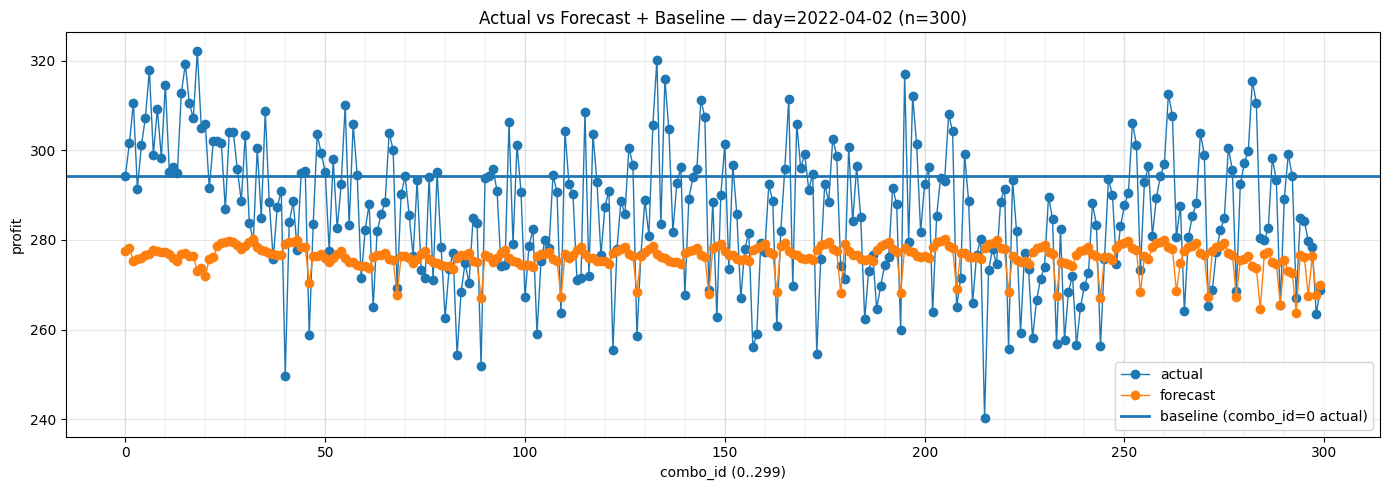

datetime.date(2022, 4, 2)

In [ ]:
plot_random_day_with_baseline(plot_df)


#### Basic RI vs. Oracle

In [ ]:
singe_ri_results = pd.read_csv("../output/single_market/rolling_intrinsic/ri_basic/qh/2019/bs15cr1rto0.86mc365mt10/profit.csv", parse_dates=["day"])
singe_ri_results["day"] = pd.to_datetime(singe_ri_results["day"].astype(str).str.slice(0, 10), errors="coerce")
singe_ri_results["day"] = singe_ri_results["day"].dt.normalize()
singe_ri_results.set_index("day", inplace=True)
singe_ri_results

,profit,cycles
day,,
2019-01-01,68.233139,1.000000
2019-01-02,159.440419,2.000000
2019-01-03,56.598649,3.000000
2019-01-04,64.915423,4.000000
2019-01-05,102.020127,5.000000
...,...,...
2023-09-26,342.531022,1729.536319
2023-09-27,307.205984,1730.536319
2023-09-28,309.449274,1731.536319


In [ ]:
summary.set_index("day", inplace=True)
summary = summary.join(singe_ri_results, lsuffix="_oracle", rsuffix="_single_ri")
summary

,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better,profit,cycles
day,,,,,,,,
2019-01-01,68.233139,119.010039,74.416772,142.0,21.450609,17.686777,68.233139,1.0
2019-01-02,159.440419,211.961910,32.941140,168.0,16.861342,17.855675,159.440419,2.0
2019-01-03,56.598649,70.577425,24.698074,38.0,7.912128,5.888537,56.598649,3.0
2019-01-04,64.915423,81.637881,25.760378,29.0,5.272558,3.797980,64.915423,4.0
2019-01-05,102.020127,123.676087,21.227145,3.0,12.765820,10.157263,102.020127,5.0
...,...,...,...,...,...,...,...,...
2023-01-31,160.698571,201.434757,25.349438,240.0,10.170875,10.126349,160.698571,1492.0
2023-02-01,148.476485,162.111428,9.183234,98.0,3.342960,2.807521,148.476485,1493.0
2023-02-02,183.455514,243.601385,32.784990,291.0,9.861867,9.781082,183.455514,1494.0


In [ ]:
summary["diff"]= summary["RI_base"] - summary["profit"]

<Axes: title={'center': 'Oracle vs Single RI Profit Comparison'}, xlabel='day'>

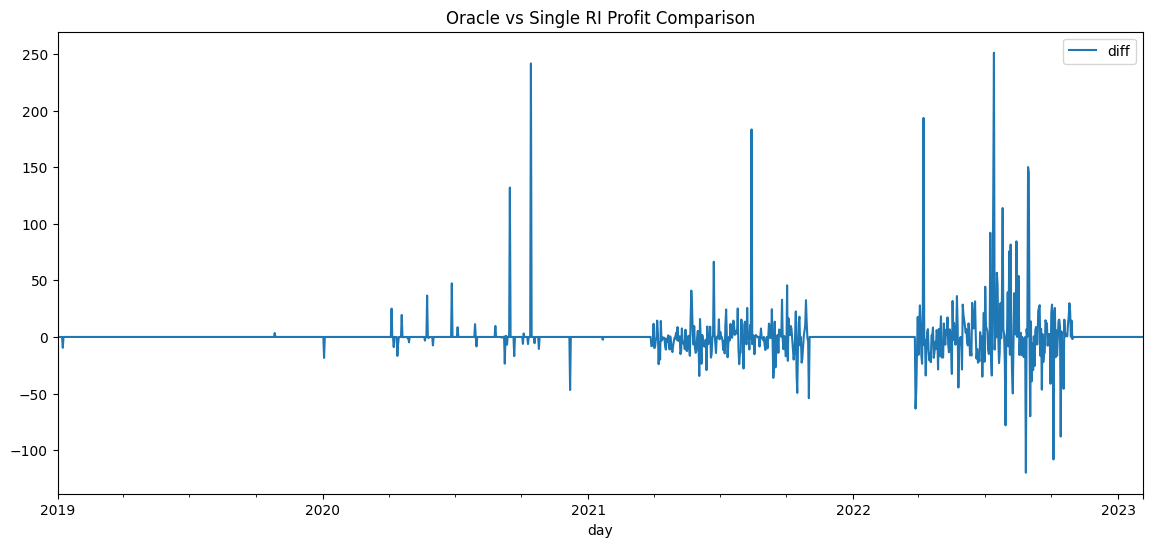

In [ ]:
summary.plot(y=["diff"], title="Oracle vs Single RI Profit Comparison", figsize=(14, 6))

In [ ]:
threshold = 0.01

n_days_diff = (summary["diff"].abs() > threshold).sum()

print(f"Anzahl Tage mit |diff| > {threshold}: {n_days_diff}")


Anzahl Tage mit |diff| > 0.01: 451


In [ ]:
summary.loc[summary["diff"].abs() > 0.01].sort_values("diff", ascending=False).head(50)


,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better,profit,cycles,diff
day,,,,,,,,,
2022-07-14,602.473204,608.713547,1.035788,2.0,0.732935,0.732935,351.281111,1291.000000,251.192093
2020-10-14,319.946301,391.511626,22.367917,35.0,7.138299,6.060253,78.238395,653.000000,241.707906
2022-04-08,647.110155,766.499093,18.449554,59.0,4.979578,4.842535,453.568182,1194.000000,193.541973
2021-08-14,328.676234,345.148255,5.011625,16.0,1.559420,1.547783,145.257764,956.808746,183.418469
2022-08-30,814.221491,876.074847,7.596625,38.0,2.244733,1.780509,664.080406,1338.000000,150.141084
2022-08-31,945.743987,1105.340230,16.875206,30.0,8.508216,12.864953,800.310770,1339.000000,145.433217
2020-09-15,905.855102,1156.318012,27.649335,36.0,14.440573,19.013788,773.818973,624.000000,132.036129
2022-07-13,795.707313,837.295987,5.226630,15.0,2.976199,3.055151,675.649048,1290.000000,120.058264
2022-07-26,1359.482542,1699.734267,25.028032,48.0,8.019018,8.140259,1245.538723,1303.000000,113.943819
